In [1]:
import pandas as pd
# df = pd.read_csv("mismatches/mismatches_merged.csv")
df = pd.read_parquet("31032026_olej_inny.parquet")
df

,Lab_Number,Sample_Condition,Sample_Type,Is_Feng,Client,Client_Device,Device_Type,Subtype,Manufacturer,Capacity,...,RPVOT_delta_p_above_1440,Corrosive_sulfur_ASTM,Fuel_content,Kinematic_viscosity_at_0C,Kinematic_viscosity_at_80C,Kinematic_viscosity_at_110C,Density_at_15_5C,Density_at_50C,Breakdown_voltage_ASTM,Standard_deviation_of_breakdown_voltage_ASTM
0,P1304659,None,None,False,10223,FI H1 - In side no.1.,Hyd,None,brak danych,330.0,...,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN
1,P1304661,None,None,False,10223,EXT H5 - 2RH Wytłaczarka nr.1.,Hyd,Serwozawory,brak danych,0.0,...,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN
2,P1304663,None,None,False,10223,EXT H7 - 2RH Wytłaczarka nr.3.,Hyd,Serwozawory,brak danych,0.0,...,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN
3,P1304666,None,None,False,10223,CAL H3 - Kompensator,Hyd,Serwozawory,brak danych,250.0,...,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN
4,P1304671,None,None,False,10223,CAL H5 - Główny Archiwalny,Hyd,Serwozawory,brak danych,970.0,...,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160444,P2605212,Pojemnik własny klienta; klarowny,Przemysłowe oleje smarowe,False,10690,BI V,In,None,Orlen Oil,NaN,...,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN
160445,P2605296,klarowny; Pojemnik własny klienta,Przemysłowe oleje smarowe,False,10690,Superol F CD SAE 15W-40,Ole,None,Orlen Oil,NaN,...,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN
160446,P2605311,Pojemnik własny klienta; klarowny,Przemysłowe oleje smarowe,False,10690,30385,In,None,Orlen Oil,NaN,...,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN
160447,P2605314,klarowny; Pojemnik własny klienta,Przemysłowe oleje smarowe,False,10690,52588,In,None,Orlen Oil,NaN,...,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN


In [2]:
df = df[df['Device_Type'] == 'Sil']

In [3]:
df[df['Lab_Number'] == 'P1805605']['Overall_Interpretation'].iloc[0]

'Oznaczenie klasy czystości oraz poziomu cząstek poszczególnych kategorii zużyciowych niemożliwe do wykonania ze względu na czarne zabarwienie membrany. W mikroskopowej obserwacji sączka nie stwierdzono metalicznych cząstek w ilości świadczącej o intensywnych procesach korozji/zużycia w smarowanym układzie. Poziom żelaza chromu, miedzi, glinu (aluminium) i srebra podniesiony, nie krytycznie. Poziom dodatków uszlachetniających w normie. Wysoki poziom ołowiu pochodzi z paliwa lotniczego i jest to normalna sytuacja dla silników lotniczych.\xa0\n\n\xa0 \xa0Wnioski i zalecenia:\nPowiązać wykryte metale zużyciowe z metalurgią układu olejowego. Proszę prowadzić ewidencję czasu pracy oleju od wymiany (czasu nalotu od wymiany) i całkowitego czasu pracy (nalotu) silnika. Przeprowadzać wymianę oleju i filtrów zgodnie z zaleceniami producenta. Proszę obserwować zmiany trendu w następnej analizie. Przysłać kolejną próbkę do badań zgodnie z przyjętym harmonogramem diagnostyki olejowej.'

In [4]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from parser import parser

In [5]:
data = parser.df_to_json(df, 0, len(df))
data

{'P1304884': {'metale_zużyciowe': 'w_normie',
  'lepkość': 'w_normie',
  'woda': 'w_normie',
  'liczba_kwasowa': 'w_normie',
  'ph': 'w_normie',
  'dodatki_uszlachetniające': 'w_normie'},
 'P1305076': {},
 'P1400113': {},
 'P1400354': {'miedź': 'podniesiony',
  'sód': 'obniżony',
  'krzem': 'obniżony',
  'lepkość': 'w_normie',
  'ph': 'w_normie',
  'liczba_kwasowa': 'w_normie',
  'liczba_zasadowa': 'obniżony',
  'trend_liczba_zasadowa': 'w_normie'},
 'P1400417': {'żelazo': 'lekko_podniesiony',
  'dodatki_uszlachetniające': 'w_normie',
  'lepkość': 'w_normie',
  'liczba_kwasowa': 'w_normie'},
 'P1400044': {'miedź': 'lekko_podniesiony',
  'lepkość': 'w_normie',
  'liczba_kwasowa': 'krytycznie_obniżony'},
 'P1305077': {},
 'P1400480': {},
 'P1400482': {},
 'P1400184': {'metale_zużyciowe': 'w_normie',
  'sód': 'obniżony',
  'krzem': 'obniżony',
  'lepkość': 'w_normie',
  'ph': 'w_normie',
  'liczba_kwasowa': 'w_normie',
  'liczba_zasadowa': 'obniżony'},
 'P1400003': {'miedź': 'lekko_podnie

In [6]:

# Słownik porządkujący statusy na osi "odchyłu"
STATUS_TO_ABNORMALITY = {
    # brak wiarygodnego wyniku
    "nieoznaczono": None,

    # brak wykrycia / norma
    "brak_wykrycia": 0.0,
    "w_normie": 0.0,
    "w_zakresie_typowym": 0.0,
    "w_zakresie_bezpiecznym": 0.0,
    "w_akceptowalnym_zakresie": 0.0,
    "w_dopuszczalnym_zakresie": 0.0,

    # graniczne / bardzo lekkie odchylenie
    "w_zakresie_granicznym": 0.0,
    "nieznacznie_odbiega": 0.0,

    # lekkie / małe odchylenie
    "nieznacznie_podniesiony": 0.5,
    "nieznacznie_obniżony": 0.5,
    "lekko_podniesiony": 0.5,
    "lekko_obniżony": 0.5,
    "podniesiony": 0.5,
    "obniżony": 0.5,
    "powyżej_typowego": 0.5,
    "poniżej_typowego": 0.5,
    "nietypowy": 0.5,
    "pogorszony": 0.5,
    "wysoki": 0.5,

    "wzrostowy": 0.5,
    

    # wyraźne odchylenie
    "znacznie_podniesiony": 1.0,
    "znacznie_obniżony": 1.0,
    "mocno_podwyższony": 1.0,
    "mocno_obniżony": 1.0,
    "mocno_pogorszony": 1.0,
    "poza_dopuszczalnym_zakresem": 1.0,
    "powyżej_dopuszczalnego_limitu": 1.0,

    # krytyczne
    "krytycznie_podniesiony": 1.0,
    "krytycznie_obniżony": 1.0,
}

abnormality,0.0,0.5,1.0,abnormal_total
key,,,,
miedź,21689,1813,513,2326
lepkość,21858,1948,209,2157
temperatura_zapłonu,21899,1726,390,2116
paliwo,22568,1202,245,1447
sód,22717,1110,188,1298
...,...,...,...,...
oznaczone_parametry,24015,0,0,0
pozostałe_parametry,24015,0,0,0
trend_sulfacja,24015,0,0,0


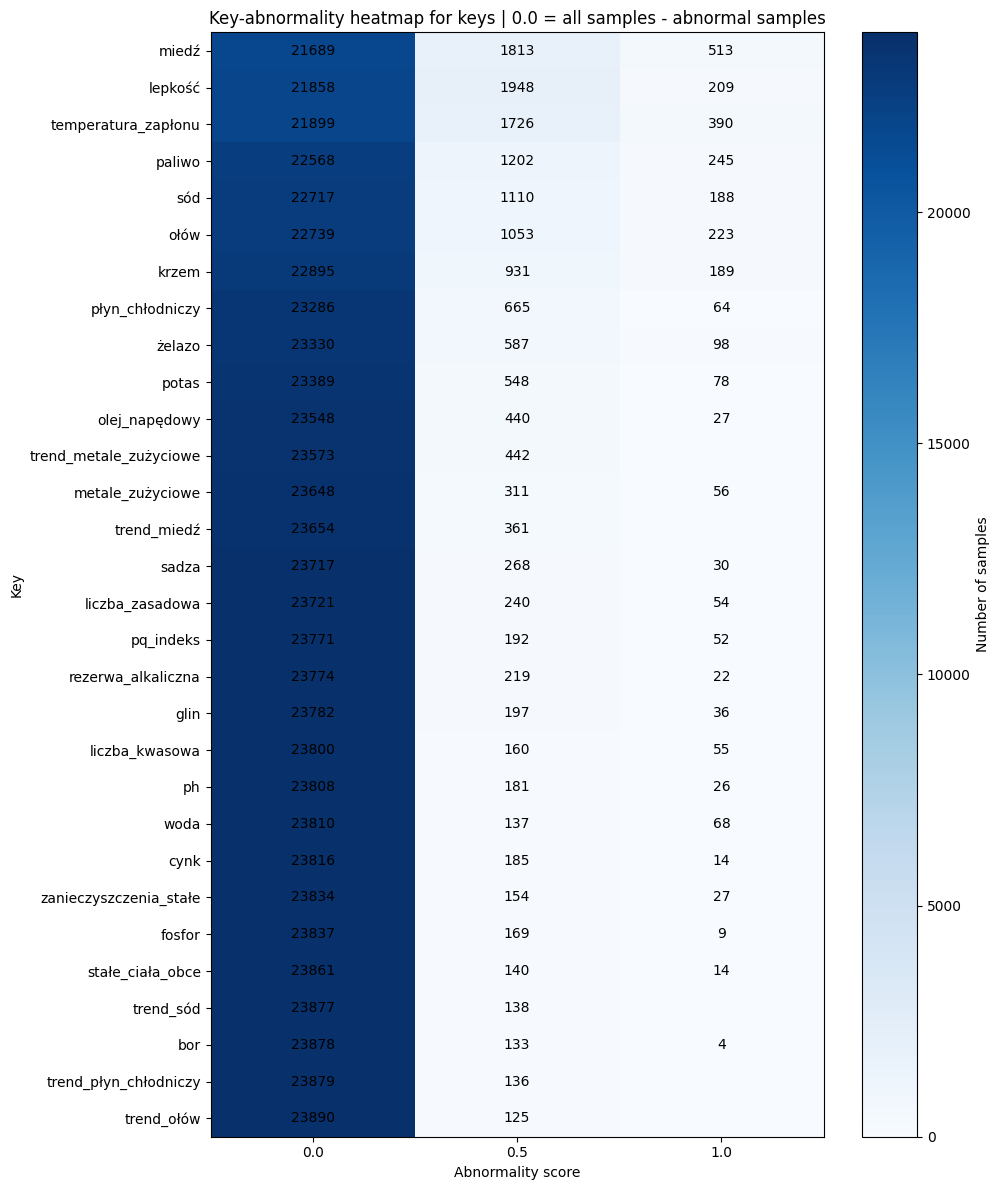


Total samples used for implicit 0.0: 24015

Unknown values not found in STATUS_TO_ABNORMALITY:


,value,count
0,spadkowy,440
1,do_obserwacji,107
2,odbiega_od_referencji,3



Values skipped because they are mapped to None:


,value,count
0,nieoznaczono,14


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# ============================================================
# SETTINGS
# ============================================================

KEY_MODE = "all"              # "all" or "trend"
TOP_N_KEYS = 30

USE_IMPLICIT_ZERO = True      # if True: 0.0 = all samples - abnormal samples for this key
SHOW_ZERO_COL = True          # if False: compute 0.0 but do not plot it

TOTAL_SAMPLE_MODE = "all"     # "all" or "with_any_keys"
FIG_WIDTH = 10


# ============================================================
# HELPERS
# ============================================================

def should_use_key(key, key_mode):
    if key_mode == "all":
        return True

    if key_mode == "trend":
        return str(key).startswith("trend_")

    raise ValueError("KEY_MODE must be either 'all' or 'trend'")


def get_total_sample_count(data, mode="all"):
    if mode == "all":
        return len(data)

    if mode == "with_any_keys":
        return sum(
            isinstance(values, dict) and len(values) > 0
            for values in data.values()
        )

    raise ValueError("TOTAL_SAMPLE_MODE must be either 'all' or 'with_any_keys'")


def filter_columns_for_plot(matrix, show_zero=True):
    cols_to_keep = []

    for col in matrix.columns:
        if col == "abnormal_total":
            continue

        if not show_zero and col == 0.0:
            continue

        cols_to_keep.append(col)

    return matrix[cols_to_keep]


# ============================================================
# BUILD LONG DATAFRAME
# ============================================================

rows = []
unknown_values = Counter()
skipped_none_values = Counter()

total_samples = get_total_sample_count(data, TOTAL_SAMPLE_MODE)

for lab_number, values in data.items():
    if not isinstance(values, dict) or len(values) == 0:
        continue

    for key, value in values.items():
        if not should_use_key(key, KEY_MODE):
            continue

        if value not in STATUS_TO_ABNORMALITY:
            unknown_values[value] += 1
            continue

        abnormality = STATUS_TO_ABNORMALITY[value]

        if abnormality is None:
            skipped_none_values[value] += 1
            continue

        rows.append({
            "Lab_Number": lab_number,
            "key": key,
            "value": value,
            "abnormality": abnormality,
        })


long_df = pd.DataFrame(rows)


# ============================================================
# BUILD HEATMAP MATRIX
# ============================================================

if long_df.empty:
    print("No matching key/value combinations found.")

else:
    heatmap_df = (
        long_df
        .assign(count=1)
        .pivot_table(
            index="key",
            columns="abnormality",
            values="count",
            aggfunc="sum",
            fill_value=0,
        )
    )

    # Ensure standard abnormality columns exist
    for col in [0.0, 0.5, 1.0]:
        if col not in heatmap_df.columns:
            heatmap_df[col] = 0

    # Sort columns numerically
    heatmap_df = heatmap_df.reindex(sorted(heatmap_df.columns), axis=1)

    if USE_IMPLICIT_ZERO:
        # Only abnormal columns count as "key is present as abnormal"
        abnormal_cols = [col for col in heatmap_df.columns if col != 0.0]

        abnormal_count = heatmap_df[abnormal_cols].sum(axis=1)

        # 0.0 means: all samples minus samples where this key has abnormal value
        heatmap_df[0.0] = total_samples - abnormal_count

        # Safety: avoid negative values
        heatmap_df[0.0] = heatmap_df[0.0].clip(lower=0).astype(int)

    # Sort columns again because 0.0 was overwritten
    heatmap_df = heatmap_df.reindex(sorted(heatmap_df.columns), axis=1)

    # Sort rows by abnormal samples only, not by implicit normal count
    abnormal_cols = [col for col in heatmap_df.columns if col != 0.0]
    heatmap_df["abnormal_total"] = heatmap_df[abnormal_cols].sum(axis=1)

    heatmap_df = heatmap_df.sort_values("abnormal_total", ascending=False)

    display(heatmap_df)


    # ============================================================
    # PLOT
    # ============================================================

    heatmap_plot = filter_columns_for_plot(
        heatmap_df,
        show_zero=SHOW_ZERO_COL,
    ).head(TOP_N_KEYS)

    if heatmap_plot.empty:
        print("No columns selected for plotting.")

    else:
        fig_height = max(6, 0.4 * len(heatmap_plot))
        plt.figure(figsize=(FIG_WIDTH, fig_height))

        im = plt.imshow(heatmap_plot.values, aspect="auto", cmap="Blues")

        plt.colorbar(im, label="Number of samples")

        plt.xticks(
            ticks=range(len(heatmap_plot.columns)),
            labels=heatmap_plot.columns,
            rotation=0,
        )

        plt.yticks(
            ticks=range(len(heatmap_plot.index)),
            labels=heatmap_plot.index,
        )

        # Add numbers inside cells
        for i in range(len(heatmap_plot.index)):
            for j in range(len(heatmap_plot.columns)):
                cell_value = heatmap_plot.iloc[i, j]

                if cell_value > 0:
                    plt.text(
                        j,
                        i,
                        str(int(cell_value)),
                        ha="center",
                        va="center",
                    )

        title_key_part = "trend keys" if KEY_MODE == "trend" else "keys"

        title_parts = [f"Key-abnormality heatmap for {title_key_part}"]

        if USE_IMPLICIT_ZERO:
            title_parts.append("0.0 = all samples - abnormal samples")

        plt.title(" | ".join(title_parts))
        plt.xlabel("Abnormality score")
        plt.ylabel("Key")
        plt.tight_layout()
        plt.show()


# ============================================================
# DIAGNOSTICS
# ============================================================

print(f"\nTotal samples used for implicit 0.0: {total_samples}")

if unknown_values:
    print("\nUnknown values not found in STATUS_TO_ABNORMALITY:")
    display(
        pd.DataFrame(
            unknown_values.items(),
            columns=["value", "count"]
        )
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

if skipped_none_values:
    print("\nValues skipped because they are mapped to None:")
    display(
        pd.DataFrame(
            skipped_none_values.items(),
            columns=["value", "count"]
        )
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

In [8]:
import pandas as pd
from collections import Counter

# ============================================================
# SETTINGS
# ============================================================

TOP_N_KEYS = 100
KEY_MODE = "all"  # "all" or "trend"

OUTPUT_ZERO_FOR_MISSING_KEY = True
# True  -> if sample does not have this key, put 0.0
# False -> if sample does not have this key, put NaN


# ============================================================
# HELPERS
# ============================================================

def should_use_key(key, key_mode):
    if key_mode == "all":
        return True

    if key_mode == "trend":
        return str(key).startswith("trend_")

    raise ValueError("KEY_MODE must be either 'all' or 'trend'")


def value_to_score(value):
    """
    Convert parser value directly using STATUS_TO_ABNORMALITY.

    Expected output:
    - 0.0
    - 0.5
    - 1.0
    - pd.NA for unknown / skipped values
    """
    if value not in STATUS_TO_ABNORMALITY:
        return pd.NA

    score = STATUS_TO_ABNORMALITY[value]

    if score is None:
        return pd.NA

    return score


# ============================================================
# FIND TOP N MOST POPULAR KEYS
# ============================================================

key_counter = Counter()

for lab_number, values in data.items():
    if not isinstance(values, dict) or len(values) == 0:
        continue

    for key in values.keys():
        if should_use_key(key, KEY_MODE):
            key_counter[key] += 1

top_keys = [key for key, count in key_counter.most_common(TOP_N_KEYS)]

print("Top keys:")
for key in top_keys:
    print(f"{key}: {key_counter[key]}")


# ============================================================
# BUILD FEATURES DATAFRAME
# ============================================================

rows = []
unknown_values = Counter()
skipped_none_values = Counter()

for lab_number, values in data.items():
    row = {"Lab_Number": str(lab_number)}

    if not isinstance(values, dict):
        values = {}

    for key in top_keys:
        if key in values:
            raw_value = values[key]

            if raw_value not in STATUS_TO_ABNORMALITY:
                unknown_values[raw_value] += 1
                score = pd.NA
            elif STATUS_TO_ABNORMALITY[raw_value] is None:
                skipped_none_values[raw_value] += 1
                score = pd.NA
            else:
                score = STATUS_TO_ABNORMALITY[raw_value]

        else:
            score = 0.0 if OUTPUT_ZERO_FOR_MISSING_KEY else pd.NA

        row[key] = score

    rows.append(row)

features_df = pd.DataFrame(rows)
features_df = features_df[["Lab_Number"] + top_keys]


# ============================================================
# ADD OVERALL_ASSESSMENT TARGET FROM df
# ============================================================

ASSESSMENT_MAP = {
    "W NORMIE": 0,
    "WSKAZÓWKA": 1,
    "UWAGA": 2,
}

assessment_df = df[["Lab_Number", "Overall_Assessment"]].copy()

assessment_df["Lab_Number"] = assessment_df["Lab_Number"].astype(str)

assessment_df["Overall_Assessment_clean"] = (
    assessment_df["Overall_Assessment"]
    .astype(str)
    .str.strip()
    .str.upper()
)

assessment_df["Overall_Assessment_mapped"] = (
    assessment_df["Overall_Assessment_clean"]
    .map(ASSESSMENT_MAP)
)

features_df = features_df.merge(
    assessment_df[["Lab_Number", "Overall_Assessment", "Overall_Assessment_mapped"]],
    on="Lab_Number",
    how="left",
)


# ============================================================
# DISPLAY
# ============================================================

display(features_df)

print("Shape:", features_df.shape)

print("\nOverall_Assessment_mapped counts:")
display(
    features_df["Overall_Assessment_mapped"]
    .value_counts(dropna=False)
    .sort_index()
)

if unknown_values:
    print("\nUnknown values not found in STATUS_TO_ABNORMALITY:")
    display(
        pd.DataFrame(
            unknown_values.items(),
            columns=["value", "count"]
        )
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

if skipped_none_values:
    print("\nValues skipped because they are mapped to None:")
    display(
        pd.DataFrame(
            skipped_none_values.items(),
            columns=["value", "count"]
        )
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

Top keys:
lepkość: 12455
temperatura_zapłonu: 11096
metale_zużyciowe: 10771
woda: 6085
liczba_zasadowa: 5743
płyn_chłodniczy: 3722
oznaczone_parametry: 3313
paliwo: 3219
pq_indeks: 3014
miedź: 2513
pozostałe_parametry: 2116
stałe_ciała_obce: 1753
zanieczyszczenia_stałe: 1569
ołów: 1344
sód: 1316
olej_napędowy: 1265
wskaźnik_lepkości: 1197
krzem: 1195
rezerwa_alkaliczna: 1023
liczba_kwasowa: 852
trend_miedź: 827
żelazo: 737
glikol: 721
trend_metale_zużyciowe: 668
ph: 644
potas: 629
sadza: 477
oksydacja: 460
nitracja: 328
trend_lepkość: 307
trend_sód: 285
klasa_czystości: 263
dodatki_uszlachetniające: 258
glin: 258
trend_ołów: 215
cynk: 206
trend_żelazo: 195
fosfor: 183
trend_krzem: 173
trend_płyn_chłodniczy: 173
sulfacja: 138
bor: 138
trend_cynk: 113
trend_ogólny: 107
cyna: 107
trend_potas: 106
trend_paliwo: 105
własności_filtrujące: 105
trend_fosfor: 101
trend_liczba_zasadowa: 73
trend_temperatura_zapłonu: 64
trend_glin: 49
trend_zanieczyszczenia_stałe: 48
trend_bor: 43
pozostałość_po_

,Lab_Number,lepkość,temperatura_zapłonu,metale_zużyciowe,woda,liczba_zasadowa,płyn_chłodniczy,oznaczone_parametry,paliwo,pq_indeks,...,trend_wskaźnik_lepkości,trend_rezerwa_alkaliczna,trend_biokomponenty,trend_sulfacja,trend_temperatura_krystalizacji,trend_magnez,trend_pozostałość_po_spopieleniu,trend_azotyny,Overall_Assessment,Overall_Assessment_mapped
0,P1304884,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,W NORMIE,0.0
1,P1305076,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BRAK,NaN
2,P1400113,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,W NORMIE,0.0
3,P1400354,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WSKAZÓWKA,1.0
4,P1400417,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WSKAZÓWKA,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24011,P2605122,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,W NORMIE,0.0
24012,P2605167,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,WSKAZÓWKA,1.0
24013,P2605169,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,W NORMIE,0.0
24014,P2605173,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,W NORMIE,0.0


Shape: (24016, 85)

Overall_Assessment_mapped counts:


Overall_Assessment_mapped
0.0    12419
1.0     6551
2.0     3160
NaN     1886
Name: count, dtype: int64


Unknown values not found in STATUS_TO_ABNORMALITY:


,value,count
0,spadkowy,440
1,do_obserwacji,107
2,odbiega_od_referencji,3



Values skipped because they are mapped to None:


,value,count
0,nieoznaczono,14


In [9]:
features_df.to_csv("explanations.csv", index=False)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# HEATMAP: keys x abnormality score
# ============================================================

def build_key_abnormality_matrix(data, key_mode="all", status_to_abnormality=None):
    rows = []

    if status_to_abnormality is None:
        status_to_abnormality = STATUS_TO_ABNORMALITY

    unknown_values = Counter()

    for lab_number, values in data.items():
        if not isinstance(values, dict) or len(values) == 0:
            continue

        for key, value in values.items():
            if not key_filter(key, key_mode):
                continue

            abnormality = status_to_abnormality.get(value)

            # skip values mapped to None, e.g. "nieoznaczono"
            if abnormality is None:
                if value not in status_to_abnormality:
                    unknown_values[value] += 1
                continue

            rows.append({
                "key": key,
                "abnormality": abnormality,
                "count": 1,
            })

    long_df = pd.DataFrame(rows)

    if long_df.empty:
        return pd.DataFrame(), long_df, unknown_values

    matrix = (
        long_df
        .pivot_table(
            index="key",
            columns="abnormality",
            values="count",
            aggfunc="sum",
            fill_value=0,
        )
    )

    # Ensure nice column order
    matrix = matrix.reindex(sorted(matrix.columns), axis=1)

    # Sort keys by total count
    matrix = matrix.loc[matrix.sum(axis=1).sort_values(ascending=False).index]

    return matrix, long_df, unknown_values


def plot_key_abnormality_heatmap(
    data,
    key_mode="all",
    top_n_keys=30,
    status_to_abnormality=None,
):
    matrix, long_df, unknown_values = build_key_abnormality_matrix(
        data=data,
        key_mode=key_mode,
        status_to_abnormality=status_to_abnormality,
    )

    if matrix.empty:
        print("No key/abnormality combinations found.")
        return matrix

    matrix_plot = matrix.head(top_n_keys).copy()

    plt.figure(figsize=(10, max(6, 0.4 * len(matrix_plot))))

    sns.heatmap(
        matrix_plot,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=0.5,
        cbar_kws={"label": "Number of samples"},
    )

    title_key_part = "trend keys" if key_mode == "trend" else "keys"
    plt.title(f"Key-abnormality counts heatmap for {title_key_part}")
    plt.xlabel("Abnormality score")
    plt.ylabel("Key")
    plt.tight_layout()
    plt.show()

    if unknown_values:
        print("Unknown values not found in STATUS_TO_ABNORMALITY:")
        display(
            pd.DataFrame(
                unknown_values.items(),
                columns=["value", "count"]
            )
            .sort_values("count", ascending=False)
            .reset_index(drop=True)
        )

    return matrix


key_abnormality_matrix = plot_key_abnormality_heatmap(
    data=data,
    key_mode=KEY_MODE,          # "all" or "trend"
    top_n_keys=30,
    status_to_abnormality=STATUS_TO_ABNORMALITY,
)

display(key_abnormality_matrix)

NameError: name 'key_filter' is not defined

Summary:
total_samples_in_data: 24015
samples_with_any_keys: 20832
samples_used_after_key_filter: 20832
keys_found: 82
total_key_occurrences: 85338
missing_date_or_unmatched_occurrences: 0


,key,before,after,missing_date,total
0,lepkość,9693,2762,0,12455
1,temperatura_zapłonu,8352,2744,0,11096
2,metale_zużyciowe,8440,2331,0,10771
3,woda,3627,2458,0,6085
4,liczba_zasadowa,3438,2305,0,5743
...,...,...,...,...,...
77,trend_temperatura_krystalizacji,2,0,0,2
78,trend_sulfacja,2,0,0,2
79,trend_magnez,2,0,0,2
80,trend_azotyny,1,0,0,1


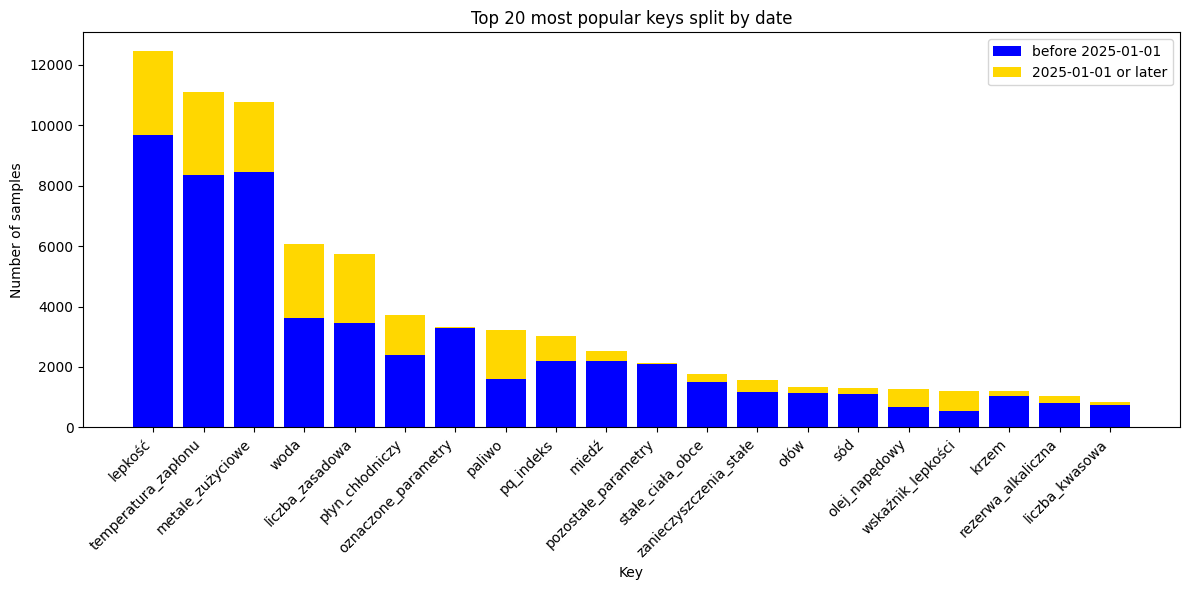

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# ============================================================
# SETTINGS
# ============================================================

SPLIT_DATE = "2025-01-01"

# Options:
# "all"   -> use all parsed keys
# "trend" -> use only keys starting with "trend_"
KEY_MODE = "all"

TOP_N = 20

BEFORE_LABEL = f"before {SPLIT_DATE}"
AFTER_LABEL = f"{SPLIT_DATE} or later"


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def key_filter(key, mode="all"):
    """Decide whether a key should be counted."""
    if mode == "all":
        return True

    if mode == "trend":
        return str(key).startswith("trend_")

    raise ValueError("KEY_MODE must be either 'all' or 'trend'")


def prepare_lab_periods(df, split_date):
    """Create Lab_Number -> before/after split mapping."""
    date_df = df[["Lab_Number", "Sample_Collection_Date"]].copy()

    date_df["Lab_Number"] = date_df["Lab_Number"].astype(str)
    date_df["Sample_Collection_Date"] = pd.to_datetime(
        date_df["Sample_Collection_Date"],
        errors="coerce"
    )

    split_date = pd.Timestamp(split_date)

    date_df["period"] = date_df["Sample_Collection_Date"].apply(
        lambda x:
        "before" if pd.notna(x) and x < split_date
        else "after" if pd.notna(x)
        else "missing_date"
    )

    return dict(zip(date_df["Lab_Number"], date_df["period"]))


def count_keys_by_period(data, lab_to_period, key_mode="all"):
    """Count parsed keys split into before/after/missing_date."""
    before_counter = Counter()
    after_counter = Counter()
    missing_date_counter = Counter()

    samples_with_keys = 0
    samples_used = 0

    for lab_number, values in data.items():
        if not isinstance(values, dict) or len(values) == 0:
            continue

        samples_with_keys += 1

        selected_keys = [
            key for key in values.keys()
            if key_filter(key, key_mode)
        ]

        if len(selected_keys) == 0:
            continue

        samples_used += 1

        lab_number = str(lab_number)
        period = lab_to_period.get(lab_number, "missing_date")

        for key in selected_keys:
            if period == "before":
                before_counter[key] += 1
            elif period == "after":
                after_counter[key] += 1
            else:
                missing_date_counter[key] += 1

    all_keys = set(before_counter) | set(after_counter) | set(missing_date_counter)

    counts_df = pd.DataFrame({"key": sorted(all_keys)})

    counts_df["before"] = counts_df["key"].map(before_counter).fillna(0).astype(int)
    counts_df["after"] = counts_df["key"].map(after_counter).fillna(0).astype(int)
    counts_df["missing_date"] = counts_df["key"].map(missing_date_counter).fillna(0).astype(int)

    counts_df["total"] = (
        counts_df["before"]
        + counts_df["after"]
        + counts_df["missing_date"]
    )

    counts_df = counts_df.sort_values("total", ascending=False).reset_index(drop=True)

    summary = {
        "total_samples_in_data": len(data),
        "samples_with_any_keys": samples_with_keys,
        "samples_used_after_key_filter": samples_used,
        "keys_found": len(counts_df),
        "total_key_occurrences": int(counts_df["total"].sum()),
        "missing_date_or_unmatched_occurrences": int(counts_df["missing_date"].sum()),
    }

    return counts_df, summary


def plot_key_histogram(counts_df, split_date, key_mode="all", top_n=20):
    """Plot top N keys as stacked before/after bars."""
    top_df = counts_df.head(top_n).copy()

    plt.figure(figsize=(12, 6))

    plt.bar(
        top_df["key"],
        top_df["before"],
        label=f"before {split_date}",
        color="blue",
    )

    plt.bar(
        top_df["key"],
        top_df["after"],
        bottom=top_df["before"],
        label=f"{split_date} or later",
        color="gold",
    )

    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Key")
    plt.ylabel("Number of samples")

    title_key_part = "trend keys" if key_mode == "trend" else "keys"
    plt.title(f"Top {top_n} most popular {title_key_part} split by date")

    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# RUN
# ============================================================

lab_to_period = prepare_lab_periods(df, SPLIT_DATE)

counts_df, summary = count_keys_by_period(
    data=data,
    lab_to_period=lab_to_period,
    key_mode=KEY_MODE,
)

print("Summary:")
for k, v in summary.items():
    print(f"{k}: {v}")

display(counts_df)

plot_key_histogram(
    counts_df=counts_df,
    split_date=SPLIT_DATE,
    key_mode=KEY_MODE,
    top_n=TOP_N,
)

In [ ]:
trend_data = {
    lab: parsed
    for lab, parsed in data.items()
    if any(str(k).startswith("trend_") for k in parsed.keys())
}

print(f"Samples with trend keys: {len(trend_data)} / {len(data)}")

trend_data

Samples with trend keys: 2765 / 24015


{'P1400354': {'miedź': 'podniesiony',
  'sód': 'obniżony',
  'krzem': 'obniżony',
  'lepkość': 'w_normie',
  'ph': 'w_normie',
  'liczba_kwasowa': 'w_normie',
  'liczba_zasadowa': 'obniżony',
  'trend_liczba_zasadowa': 'w_normie'},
 'P1401292': {'cynk': 'podniesiony',
  'fosfor': 'podniesiony',
  'trend_cynk': 'w_normie',
  'trend_fosfor': 'w_normie'},
 'P1401502': {'trend_ogólny': 'w_normie'},
 'P1401503': {'trend_ogólny': 'w_normie'},
 'P1401612': {'trend_ogólny': 'w_normie'},
 'P1401770': {'cynk': 'lekko_podniesiony',
  'fosfor': 'lekko_podniesiony',
  'trend_cynk': 'w_normie',
  'trend_fosfor': 'w_normie'},
 'P1401771': {'cynk': 'mocno_podwyższony',
  'fosfor': 'mocno_podwyższony',
  'żelazo': 'lekko_podniesiony',
  'miedź': 'lekko_podniesiony',
  'trend_żelazo': 'w_normie',
  'trend_miedź': 'w_normie'},
 'P1401775': {'trend_ogólny': 'w_normie'},
 'P1401978': {'trend_ogólny': 'w_normie'},
 'P1500089': {'cynk': 'podniesiony',
  'trend_cynk': 'w_normie',
  'trend_fosfor': 'w_normie'}

In [ ]:
trend_miedz_data = {
    lab: parsed
    for lab, parsed in data.items()
    if "trend_miedź" in parsed
}

print(f"Samples with trend_miedź: {len(trend_miedz_data)} / {len(data)}")

trend_miedz_data

Samples with trend_miedź: 827 / 24015


{'P1401771': {'cynk': 'mocno_podwyższony',
  'fosfor': 'mocno_podwyższony',
  'żelazo': 'lekko_podniesiony',
  'miedź': 'lekko_podniesiony',
  'trend_żelazo': 'w_normie',
  'trend_miedź': 'w_normie'},
 'P1402114': {'fosfor': 'mocno_podwyższony',
  'żelazo': 'lekko_podniesiony',
  'miedź': 'lekko_podniesiony',
  'krzem': 'podniesiony',
  'trend_żelazo': 'w_normie',
  'trend_miedź': 'w_normie'},
 'P1600039': {'żelazo': 'podniesiony',
  'krzem': 'podniesiony',
  'miedź': 'podniesiony',
  'sód': 'podniesiony',
  'trend_żelazo': 'w_normie',
  'trend_krzem': 'w_normie',
  'trend_miedź': 'w_normie',
  'trend_ołów': 'w_normie'},
 'P1600058': {'lepkość': 'w_normie',
  'temperatura_zapłonu': 'w_normie',
  'dodatki_uszlachetniające': 'w_normie',
  'miedź': 'lekko_podniesiony',
  'trend_miedź': 'w_normie'},
 'P1601083': {'miedź': 'lekko_podniesiony', 'trend_miedź': 'w_normie'},
 'P1601398': {'miedź': 'podniesiony',
  'krzem': 'podniesiony',
  'trend_miedź': 'w_normie'},
 'P1601575': {'pozostałe_pa

Samples with at least one key: 20832 / 24015

Key counts:


,key,count
0,lepkość,12455
1,temperatura_zapłonu,11096
2,metale_zużyciowe,10771
3,woda,6085
4,liczba_zasadowa,5743
...,...,...
77,trend_sulfacja,2
78,trend_biokomponenty,2
79,trend_magnez,2
80,trend_pozostałość_po_spopieleniu,1



Value counts:


,value,count
0,w_normie,46799
1,podniesiony,7175
2,w_dopuszczalnym_zakresie,5314
3,w_zakresie_bezpiecznym,4935
4,brak_wykrycia,4732
5,lekko_podniesiony,3346
6,w_akceptowalnym_zakresie,2740
7,obniżony,2002
8,wzrostowy,1783
9,znacznie_podniesiony,1300



Value counts per key:


,key,value,count
0,azotyny,obniżony,15
1,azotyny,krytycznie_obniżony,7
2,azotyny,w_normie,3
3,azotyny,lekko_obniżony,2
4,azotyny,znacznie_obniżony,2
...,...,...,...
598,żelazo,powyżej_typowego,2
599,żelazo,w_zakresie_granicznym,2
600,żelazo,mocno_podwyższony,1
601,żelazo,znacznie_obniżony,1


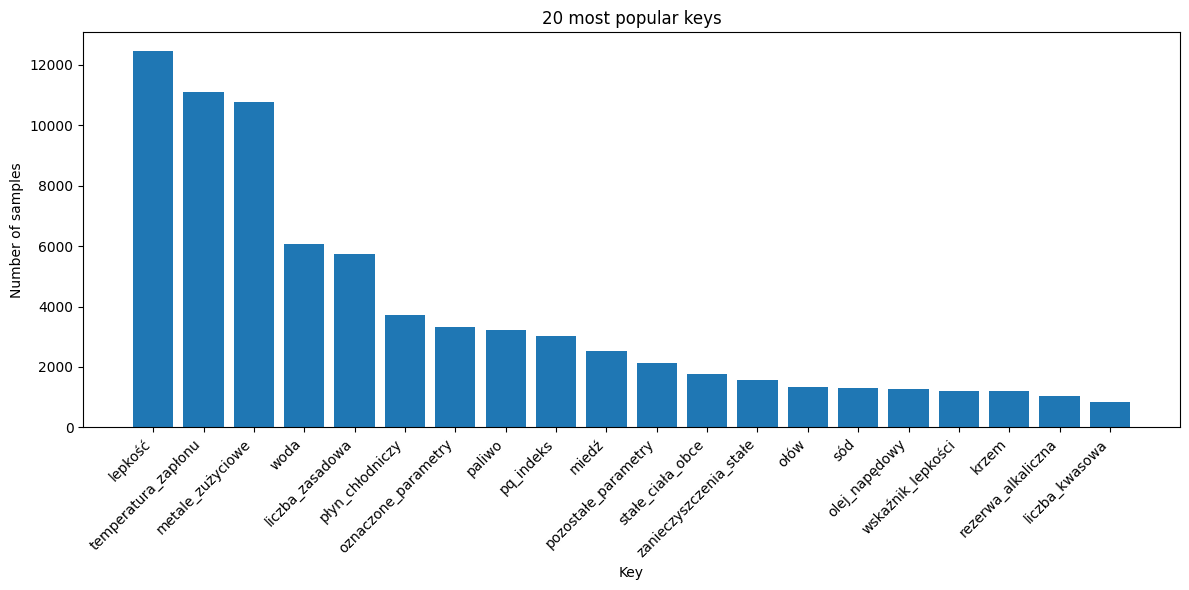

In [ ]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# data is expected to look like:
# {
#   "sample_id_1": {"key_1": "value_1", "key_2": "value_2"},
#   "sample_id_2": {"key_1": "value_3"},
#   ...
# }

# Keep only samples where parser returned a non-empty dict
samples_with_keys = {
    sample_id: values
    for sample_id, values in data.items()
    if isinstance(values, dict) and len(values) > 0
}

print(f"Samples with at least one key: {len(samples_with_keys)} / {len(data)}")

# -------------------------
# Count keys
# -------------------------
key_counter = Counter()

for values in samples_with_keys.values():
    key_counter.update(values.keys())

key_counts = (
    pd.DataFrame(key_counter.items(), columns=["key", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print("\nKey counts:")
display(key_counts)

# -------------------------
# Count values globally
# -------------------------
value_counter = Counter()

for values in samples_with_keys.values():
    value_counter.update(values.values())

value_counts = (
    pd.DataFrame(value_counter.items(), columns=["value", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print("\nValue counts:")
display(value_counts)

# -------------------------
# Count values per key
# -------------------------
key_value_counter = Counter()

for values in samples_with_keys.values():
    for key, value in values.items():
        key_value_counter[(key, value)] += 1

key_value_counts = (
    pd.DataFrame(
        [(key, value, count) for (key, value), count in key_value_counter.items()],
        columns=["key", "value", "count"]
    )
    .sort_values(["key", "count"], ascending=[True, False])
    .reset_index(drop=True)
)

print("\nValue counts per key:")
display(key_value_counts)

# -------------------------
# Histogram / bar plot of top 20 keys
# -------------------------
top20_keys = key_counts.head(20)

plt.figure(figsize=(12, 6))
plt.bar(top20_keys["key"], top20_keys["count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Key")
plt.ylabel("Number of samples")
plt.title("20 most popular keys")
plt.tight_layout()
plt.show()

In [11]:
# -------------------------
# Histogram / bar plot of top 20 trend_* keys
# -------------------------
trend_key_counts = key_counts[
    key_counts["key"].str.startswith("trend", na=False)
].copy()

print("Trend key counts:")
display(trend_key_counts)

top20_trend_keys = trend_key_counts.head(20)

plt.figure(figsize=(12, 6))
plt.bar(top20_trend_keys["key"], top20_trend_keys["count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Trend key")
plt.ylabel("Number of samples")
plt.title("20 most popular trend keys")
plt.tight_layout()
plt.show()

NameError: name 'key_counts' is not defined

In [12]:
key_name = "trend_olej_napędowy"

trend_key_samples_df = pd.DataFrame([
    {
        "Lab_Number": lab,
        key_name: parsed.get(key_name),  # <- wartość trend_miedź
    }
    for lab, parsed in data.items()
    if key_name in parsed
])

trend_key_samples_df = trend_key_samples_df.merge(
    df[["Lab_Number", "Overall_Interpretation"]],
    on="Lab_Number",
    how="left"
)

trend_key_samples_df = trend_key_samples_df[
    ["Lab_Number", "Overall_Interpretation", key_name]
]

trend_key_samples_df

,Lab_Number,Overall_Interpretation,trend_olej_napędowy
0,P1603434,Widoczny trend spadkowy w przypadku potasu ora...,spadkowy
1,P1703372,Oznaczona lepkość w normie. Poziom metalicznyc...,wzrostowy
2,P1704655,Podniesiony poziom oleju napędowego - trend wz...,wzrostowy
3,P1704660,Podniesiony poziom oleju napędowego - trend wz...,wzrostowy
4,P1801450,Poziom dodatków uszlachetniających dobrze kore...,wzrostowy
5,P1801809,Poziom dodatków uszlachetniających dobrze kore...,wzrostowy
6,P1802117,Podniesiony poziom oleju napędowego - trend st...,w_normie
7,P1802158,Krytycznie podniesiona zawartość oleju napędow...,wzrostowy
8,P1704473,Oznaczona lepkość obniżona w stosunku do oleju...,wzrostowy
9,P1801259,Poziom pierwiastków dodatków niezgodny z posia...,wzrostowy


In [13]:
df[df["Lab_Number"] == "P1604054"]["Overall_Interpretation"].iloc[0]

'Poziom miedzi jest podniesiony, trend stabilny. Klasa czystości wymaga poprawy, \nnie zaobserwowano poprawy względem poprzedniej próbki. Na membranie widoczne \nliczne metaliczne cząstki o rozmiarach >40um. Oksydacja oraz liczba kwasowa w \nnormie.\n\nZalecenia i wnioski: \nProszę sprawdzić (np. w dokumentacji technicznej urządzenia), czy taki poziom \nmiedzi jest dopuszczalny dla tego urządzenia. Jeżeli oznaczony poziom miedzi \nnie spełnia wymagań urządzenia proszę przeprowadzić kontrolę silnika \nukierunkowaną na zużycie/uszkodzenie elementów zawierających w metalurgii miedź \n(np. łożyska), a następnie przesłać kolejną próbkę do badania po \nprzeprowadzeniu działań korygujących. Jeżeli oznaczony poziom miedzi spełnia \nwymagania urządzenia proszę wykonać kolejne badanie zgodnie z przyjętym \nharmonogramem diagnostyki olejowej.'

In [14]:
lab_number = "P1604054"

data.get(lab_number)

{'miedź': 'podniesiony',
 'klasa_czystości': 'poza_dopuszczalnym_zakresem',
 'liczba_kwasowa': 'w_normie',
 'oksydacja': 'w_normie',
 'trend_miedź': 'w_normie'}

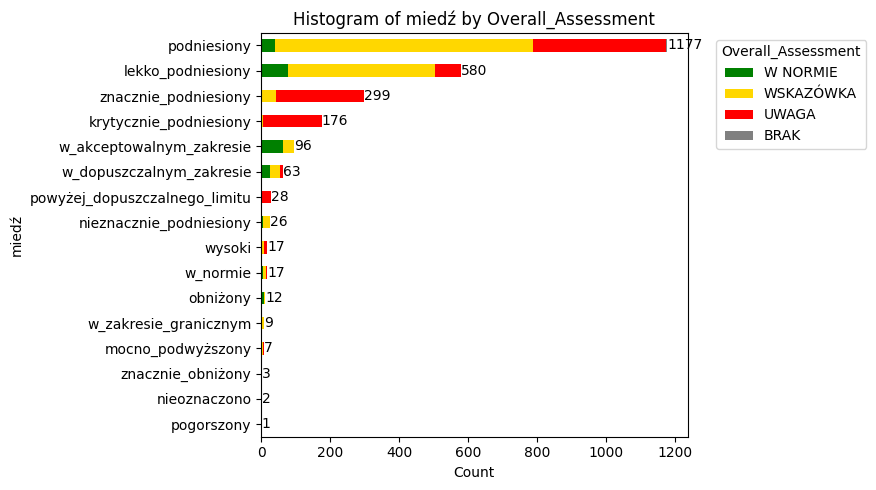

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# choose key here
# key_name = "trend_metale_zużyciowe"
key_name = "miedź"

# 1. Build dataframe for chosen key
key_df = pd.DataFrame([
    {
        "Lab_Number": lab,
        key_name: parsed.get(key_name),
    }
    for lab, parsed in data.items()
    if key_name in parsed
])

# 2. Add Overall_Assessment
key_df = key_df.merge(
    df[["Lab_Number", "Overall_Assessment"]],
    on="Lab_Number",
    how="left",
)

# 3. Normalize assessment labels
key_df["Overall_Assessment"] = (
    key_df["Overall_Assessment"]
    .fillna("BRAK")
    .astype(str)
    .str.strip()
    .str.upper()
)

# 4. Count chosen key statuses split by assessment
plot_table = pd.crosstab(
    key_df[key_name],
    key_df["Overall_Assessment"]
)

# 5. Sort bars by total count
status_order = plot_table.sum(axis=1).sort_values(ascending=True).index
plot_table = plot_table.loc[status_order]

# 6. Ensure columns/order
assessment_order = ["W NORMIE", "WSKAZÓWKA", "UWAGA", "BRAK"]

for col in assessment_order:
    if col not in plot_table.columns:
        plot_table[col] = 0

plot_table = plot_table[assessment_order]

# 7. Colors
colors = {
    "W NORMIE": "green",
    "WSKAZÓWKA": "gold",
    "UWAGA": "red",
    "BRAK": "gray",
}

# 8. Plot stacked horizontal histogram
ax = plot_table.plot(
    kind="barh",
    stacked=True,
    figsize=(9, 5),
    color=[colors[c] for c in plot_table.columns],
)

plt.xlabel("Count")
plt.ylabel(key_name)
plt.title(f"Histogram of {key_name} by Overall_Assessment")
plt.legend(title="Overall_Assessment", bbox_to_anchor=(1.05, 1), loc="upper left")

# 9. Add total labels
totals = plot_table.sum(axis=1)

for i, value in enumerate(totals):
    plt.text(value, i, str(value), va="center", ha="left")

plt.tight_layout()
plt.show()

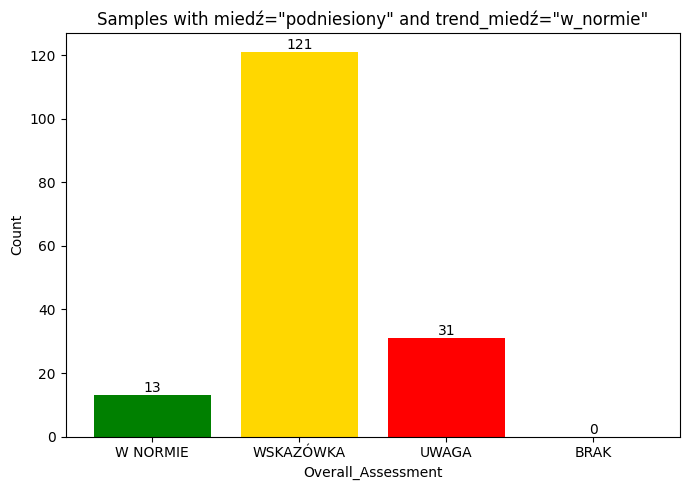

Liczba próbek: 165


,Lab_Number,miedź,trend_miedź,Overall_Assessment
0,P1600039,podniesiony,w_normie,UWAGA
1,P1601398,podniesiony,w_normie,WSKAZÓWKA
2,P1601575,podniesiony,w_normie,WSKAZÓWKA
3,P1601599,podniesiony,w_normie,W NORMIE
4,P1601808,podniesiony,w_normie,WSKAZÓWKA
...,...,...,...,...
160,P2502297,podniesiony,w_normie,WSKAZÓWKA
161,P2510472,podniesiony,w_normie,WSKAZÓWKA
162,P2510615,podniesiony,w_normie,WSKAZÓWKA
163,P2510616,podniesiony,w_normie,WSKAZÓWKA


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# warunki
feature_key = "miedź"
feature_value = "podniesiony"

trend_key = "trend_miedź"
trend_value = "w_normie"

# 1. Build dataframe for samples matching both conditions
filtered_df = pd.DataFrame([
    {
        "Lab_Number": lab,
        feature_key: parsed.get(feature_key),
        trend_key: parsed.get(trend_key),
    }
    for lab, parsed in data.items()
    if parsed.get(feature_key) == feature_value
    and parsed.get(trend_key) == trend_value
])

# 2. Add Overall_Assessment
filtered_df = filtered_df.merge(
    df[["Lab_Number", "Overall_Assessment"]],
    on="Lab_Number",
    how="left",
)

# 3. Normalize labels
filtered_df["Overall_Assessment"] = (
    filtered_df["Overall_Assessment"]
    .fillna("BRAK")
    .astype(str)
    .str.strip()
    .str.upper()
)

# 4. Count assessments
assessment_order = ["W NORMIE", "WSKAZÓWKA", "UWAGA", "BRAK"]

counts = (
    filtered_df["Overall_Assessment"]
    .value_counts()
    .reindex(assessment_order, fill_value=0)
)

# 5. Colors
colors = {
    "W NORMIE": "green",
    "WSKAZÓWKA": "gold",
    "UWAGA": "red",
    "BRAK": "gray",
}

# 6. Plot histogram
plt.figure(figsize=(7, 5))
plt.bar(
    counts.index,
    counts.values,
    color=[colors[x] for x in counts.index],
)

plt.xlabel("Overall_Assessment")
plt.ylabel("Count")
plt.title(f'Samples with {feature_key}="{feature_value}" and {trend_key}="{trend_value}"')

for i, value in enumerate(counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(f"Liczba próbek: {len(filtered_df)}")
filtered_df

In [17]:
filtered_df = filtered_df.merge(
    df[["Lab_Number", "Copper"]].copy(),
    on="Lab_Number",
    how="left"
)

filtered_df["Copper"] = pd.to_numeric(
    filtered_df["Copper"],
    errors="coerce"
)

In [18]:
filtered_df

,Lab_Number,miedź,trend_miedź,Overall_Assessment,Copper
0,P1600039,podniesiony,w_normie,UWAGA,35.0
1,P1601398,podniesiony,w_normie,WSKAZÓWKA,17.0
2,P1601575,podniesiony,w_normie,WSKAZÓWKA,18.0
3,P1601599,podniesiony,w_normie,W NORMIE,18.0
4,P1601808,podniesiony,w_normie,WSKAZÓWKA,19.0
...,...,...,...,...,...
160,P2502297,podniesiony,w_normie,WSKAZÓWKA,31.0
161,P2510472,podniesiony,w_normie,WSKAZÓWKA,153.0
162,P2510615,podniesiony,w_normie,WSKAZÓWKA,178.0
163,P2510616,podniesiony,w_normie,WSKAZÓWKA,202.0


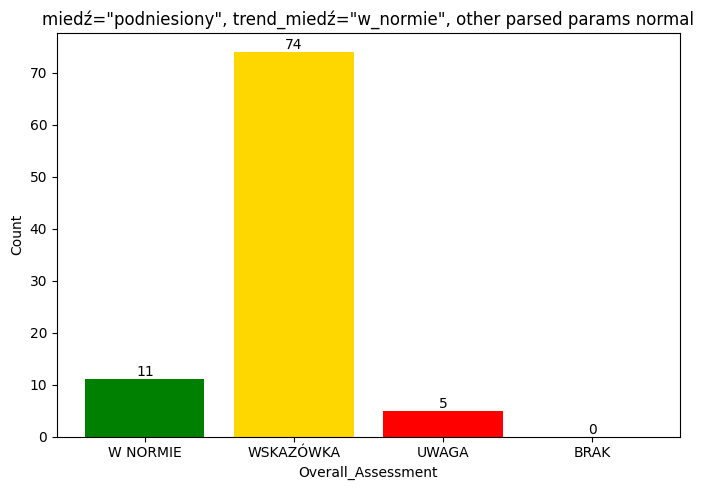

Liczba próbek: 90


,Lab_Number,Overall_Assessment,miedź,other_parsed,Overall_Interpretation
0,P1601599,W NORMIE,podniesiony,{'pozostałe_parametry': 'w_normie'},"Poziom miedzi podniesiony, trend stabilny. Wsz..."
1,P1602481,WSKAZÓWKA,podniesiony,{},"Poziom miedzi podniesiony, trend stabilny. Wsz..."
2,P1601476,W NORMIE,podniesiony,{'pozostałe_parametry': 'w_normie'},"Poziom miedzi podniesiony, trend stabilny. Wsz..."
3,P1604473,WSKAZÓWKA,podniesiony,{'pozostałe_parametry': 'w_normie'},Podniesiony poziom miedzi - trend stabilny. Po...
4,P1605277,WSKAZÓWKA,podniesiony,{'pozostałe_parametry': 'w_normie'},Podniesiony poziom miedzi - stabilny trend wzr...
...,...,...,...,...,...
85,P2316505,WSKAZÓWKA,podniesiony,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",Oznaczona lepkość w normie dla klasy SAE 40. T...
86,P2320291,WSKAZÓWKA,podniesiony,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",Oznaczona lepkość dla oleju klasy SAE 40 w nor...
87,P2320522,WSKAZÓWKA,podniesiony,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",Oznaczona lepkość w normie dla oleju klasy SAE...
88,P2401574,WSKAZÓWKA,podniesiony,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",Oznaczona lepkość dla oleju klasy SAE 40 w nor...


In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# warunki główne
feature_key = "miedź"
feature_value = "podniesiony"

trend_key = "trend_miedź"
trend_value = "w_normie"

# status uznawany za normę dla pozostałych parametrów
normal_statuses = {"w_normie"}

# jeśli chcesz traktować też dopuszczalny/akceptowalny jako "w normie", użyj tego:
# normal_statuses = {
#     "w_normie",
#     "w_dopuszczalnym_zakresie",
#     "w_akceptowalnym_zakresie",
#     "w_zakresie_bezpiecznym",
#     "w_zakresie_typowym",
# }

ignored_keys = {
    feature_key,
    trend_key,
}

rows = []

for lab, parsed in data.items():
    if parsed.get(feature_key) != feature_value:
        continue

    if parsed.get(trend_key) != trend_value:
        continue

    other_items = {
        k: v
        for k, v in parsed.items()
        if k not in ignored_keys
    }

    all_other_w_normie = all(
        value in normal_statuses
        for value in other_items.values()
    )

    if not all_other_w_normie:
        continue

    rows.append({
        "Lab_Number": lab,
        feature_key: parsed.get(feature_key),
        trend_key: parsed.get(trend_key),
        "other_parsed": other_items,
    })

filtered_df = pd.DataFrame(rows)

# Add Overall_Assessment
filtered_df = filtered_df.merge(
    df[["Lab_Number", "Overall_Assessment", "Overall_Interpretation"]],
    on="Lab_Number",
    how="left",
)

# Normalize labels
filtered_df["Overall_Assessment"] = (
    filtered_df["Overall_Assessment"]
    .fillna("BRAK")
    .astype(str)
    .str.strip()
    .str.upper()
)

# Count assessments
assessment_order = ["W NORMIE", "WSKAZÓWKA", "UWAGA", "BRAK"]

counts = (
    filtered_df["Overall_Assessment"]
    .value_counts()
    .reindex(assessment_order, fill_value=0)
)

colors = {
    "W NORMIE": "green",
    "WSKAZÓWKA": "gold",
    "UWAGA": "red",
    "BRAK": "gray",
}

plt.figure(figsize=(7, 5))
plt.bar(
    counts.index,
    counts.values,
    color=[colors[x] for x in counts.index],
)

plt.xlabel("Overall_Assessment")
plt.ylabel("Count")
plt.title(
    f'{feature_key}="{feature_value}", {trend_key}="{trend_value}", '
    f"other parsed params normal"
)

for i, value in enumerate(counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(f"Liczba próbek: {len(filtered_df)}")

filtered_df[
    ["Lab_Number", "Overall_Assessment", feature_key, "other_parsed", "Overall_Interpretation"]
]

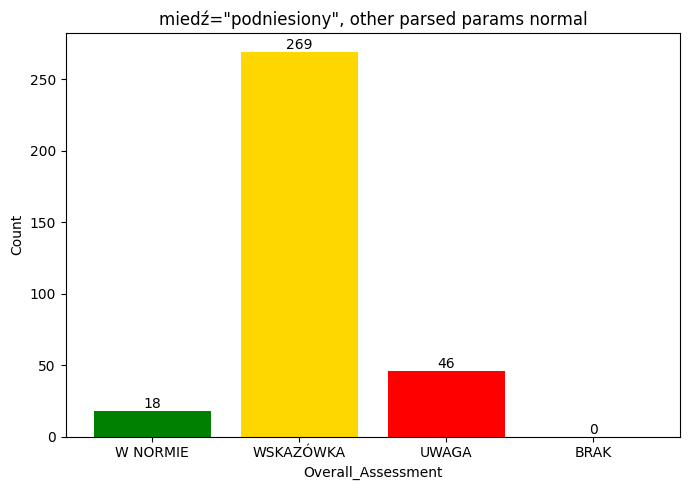

Liczba próbek: 333


,Lab_Number,Overall_Assessment,miedź,other_parsed,Overall_Interpretation
0,P1400290,WSKAZÓWKA,podniesiony,{},"Poziom miedzi podwyższony, nie krytycznie. Obs..."
1,P1503634,WSKAZÓWKA,podniesiony,{},W efekcie zużycia i/lub korozji poziom miedzi ...
2,P1600277,WSKAZÓWKA,podniesiony,{},Poziom miedzi podniesiony. Wszystkie pozostałe...
3,P1601599,W NORMIE,podniesiony,"{'pozostałe_parametry': 'w_normie', 'trend_mie...","Poziom miedzi podniesiony, trend stabilny. Wsz..."
4,P1601794,WSKAZÓWKA,podniesiony,{},Poziom miedzi podniesiony. Wszystkie pozostałe...
...,...,...,...,...,...
328,P2401678,WSKAZÓWKA,podniesiony,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",Oznaczona lepkość dla klasy SAE 40 w normie. ...
329,P2420459,UWAGA,podniesiony,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",Oznaczona lepkość w normie dla klasy SAE 40. T...
330,P2502297,WSKAZÓWKA,podniesiony,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",Oznaczona lepkość w normie dla klasy SAE 40. T...
331,P2513992,W NORMIE,podniesiony,"{'lepkość': 'w_normie', 'paliwo': 'w_normie', ...",Lepkość w normie dla oleju klasy SAE 30. Zawar...


In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# warunek główny
feature_key = "miedź"
feature_value = "podniesiony"

# status uznawany za normę dla pozostałych parametrów
normal_statuses = {"w_normie"}

# ignorujemy tylko główny parametr
ignored_keys = {
    feature_key,
}

rows = []

for lab, parsed in data.items():
    # główny warunek: miedź musi być podniesiona
    if parsed.get(feature_key) != feature_value:
        continue

    # pozostałe parametry, bez miedzi
    other_items = {
        k: v
        for k, v in parsed.items()
        if k not in ignored_keys
    }

    # wszystkie inne parametry muszą być w normie
    all_other_w_normie = all(
        value in normal_statuses
        for value in other_items.values()
    )

    if not all_other_w_normie:
        continue

    rows.append({
        "Lab_Number": lab,
        feature_key: parsed.get(feature_key),
        "other_parsed": other_items,
    })

filtered_df = pd.DataFrame(rows)

# Add Overall_Assessment
filtered_df = filtered_df.merge(
    df[["Lab_Number", "Overall_Assessment", "Overall_Interpretation"]],
    on="Lab_Number",
    how="left",
)

# Normalize labels
filtered_df["Overall_Assessment"] = (
    filtered_df["Overall_Assessment"]
    .fillna("BRAK")
    .astype(str)
    .str.strip()
    .str.upper()
)

# Count assessments
assessment_order = ["W NORMIE", "WSKAZÓWKA", "UWAGA", "BRAK"]

counts = (
    filtered_df["Overall_Assessment"]
    .value_counts()
    .reindex(assessment_order, fill_value=0)
)

colors = {
    "W NORMIE": "green",
    "WSKAZÓWKA": "gold",
    "UWAGA": "red",
    "BRAK": "gray",
}

plt.figure(figsize=(7, 5))
plt.bar(
    counts.index,
    counts.values,
    color=[colors[x] for x in counts.index],
)

plt.xlabel("Overall_Assessment")
plt.ylabel("Count")
plt.title(
    f'{feature_key}="{feature_value}", other parsed params normal'
)

for i, value in enumerate(counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(f"Liczba próbek: {len(filtered_df)}")

filtered_df[
    ["Lab_Number", "Overall_Assessment", feature_key, "other_parsed", "Overall_Interpretation"]
]

In [76]:
filtered_df = filtered_df.merge(
    df[["Lab_Number", "Copper", "Client", "Client_Device", "Lubricant_Name", 'Manufacturer', "Sample_Collection_Date", "Device_Type"]].copy(),
    on="Lab_Number",
    how="left"
)

filtered_df["Copper"] = pd.to_numeric(
    filtered_df["Copper"],
    errors="coerce"
)

In [77]:
filtered_df

,Lab_Number,miedź,trend_miedź,other_parsed,Overall_Assessment,Overall_Interpretation,Copper,Client,Client_Device,Lubricant_Name,Manufacturer,Sample_Collection_Date,Device_Type
0,P1601599,podniesiony,w_normie,{'pozostałe_parametry': 'w_normie'},W NORMIE,"Poziom miedzi podniesiony, trend stabilny. Wsz...",18.0,21802,SM42-1303 (P4 - 05/2019),Shell Rimula R4 X 15W40,CATERPILLAR,2016-04-21 12:54:00,Sil
1,P1602481,podniesiony,w_normie,{},WSKAZÓWKA,"Poziom miedzi podniesiony, trend stabilny. Wsz...",19.0,21802,SM42-1250 (P4 - 05/2018),Shell Rimula R4 X 15W40,CATERPILLAR,2016-06-10 14:47:00,Sil
2,P1601476,podniesiony,w_normie,{'pozostałe_parametry': 'w_normie'},W NORMIE,"Poziom miedzi podniesiony, trend stabilny. Wsz...",16.0,21802,SM42-1210,Shell Rimula R4 X 15W40,CATERPILLAR,2016-04-05 10:44:00,Sil
3,P1604473,podniesiony,w_normie,{'pozostałe_parametry': 'w_normie'},WSKAZÓWKA,Podniesiony poziom miedzi - trend stabilny. Po...,40.0,10845,DE6400-6485,Shell Rimula R6 10W40,brak danych,2016-10-23 08:41:00,Sil
4,P1605277,podniesiony,w_normie,{'pozostałe_parametry': 'w_normie'},WSKAZÓWKA,Podniesiony poziom miedzi - stabilny trend wzr...,25.0,21802,SM42-1229 (P4 - 11/2019),Shell Rimula R4 X 15W40,CATERPILLAR,2016-12-05 10:10:00,Sil
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,P2316505,podniesiony,w_normie,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",WSKAZÓWKA,Oznaczona lepkość w normie dla klasy SAE 40. T...,19.0,21802,SM42-1218,brak danych,CATERPILLAR,2023-10-10 00:00:00,Sil
86,P2320291,podniesiony,w_normie,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",WSKAZÓWKA,Oznaczona lepkość dla oleju klasy SAE 40 w nor...,27.0,21802,SM42-1227,Shell Rimula R4 X 15W40,CATERPILLAR,2023-12-08 00:00:00,Sil
87,P2320522,podniesiony,w_normie,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",WSKAZÓWKA,Oznaczona lepkość w normie dla oleju klasy SAE...,18.0,21802,SM42-1271,Shell Rimula R4 X 15W40,CATERPILLAR,2023-12-11 00:00:00,Sil
88,P2401574,podniesiony,w_normie,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",WSKAZÓWKA,Oznaczona lepkość dla oleju klasy SAE 40 w nor...,14.0,21802,SM42-1220,Shell Rimula R4 X 15W40,CATERPILLAR,2024-01-28 09:30:00,Sil


In [78]:
filtered_df.to_csv("filtered_samples.csv", index=False)

In [79]:
df[df["Lab_Number"] == "P2212506"]

,Lab_Number,Sample_Condition,Sample_Type,Is_Feng,Client,Client_Device,Device_Type,Subtype,Manufacturer,Capacity,...,RPVOT_delta_p_above_1440,Corrosive_sulfur_ASTM,Fuel_content,Kinematic_viscosity_at_0C,Kinematic_viscosity_at_80C,Kinematic_viscosity_at_110C,Density_at_15_5C,Density_at_50C,Breakdown_voltage_ASTM,Standard_deviation_of_breakdown_voltage_ASTM
72928,P2212506,ciemny; Pojemnik PET 200ml,Przemysłowe oleje smarowe,False,21802,SM42-1210,Sil,Diesel Caterpillar C-27,CATERPILLAR,140.0,...,None,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN


In [80]:
import re
from difflib import SequenceMatcher

def normalize_text(x):
    x = str(x).lower().strip()
    x = re.sub(r"\s+", " ", x)
    return x

tmp = filtered_df.copy()
tmp["interp_norm"] = tmp["Overall_Interpretation"].apply(normalize_text)

# exact same interpretation, different assessment
same_interp_diff_assessment = (
    tmp.groupby("interp_norm")
    .filter(lambda g: g["Overall_Assessment"].nunique() > 1)
    .sort_values("interp_norm")
)

same_interp_diff_assessment[
    ["Lab_Number", "Overall_Assessment", "Overall_Interpretation"]
]

,Lab_Number,Overall_Assessment,Overall_Interpretation
45,P2212506,WSKAZÓWKA,Oznaczona lepkość w normie dla oleju klasy SAE...
51,P2304292,WSKAZÓWKA,Oznaczona lepkość w normie dla oleju klasy SAE...
77,P2212507,WSKAZÓWKA,Oznaczona lepkość w normie dla oleju klasy SAE...
78,P2212509,W NORMIE,Oznaczona lepkość w normie dla oleju klasy SAE...


In [81]:
df_inconsistent = df[
    df["Lab_Number"].isin(filtered_df["Lab_Number"])
].copy()
df_inconsistent = df_inconsistent.dropna(axis=1, how="all")

In [82]:
df_inconsistent[['Sample_Collection_Date', 'Overall_Assessment', 'Copper', 'Client_Device', 'Client']]

,Sample_Collection_Date,Overall_Assessment,Copper,Client_Device,Client
4982,2016-04-21 12:54:00,W NORMIE,18,SM42-1303 (P4 - 05/2019),21802
5712,2016-06-10 14:47:00,WSKAZÓWKA,19,SM42-1250 (P4 - 05/2018),21802
8109,2016-04-05 10:44:00,W NORMIE,16,SM42-1210,21802
10312,2016-10-23 08:41:00,WSKAZÓWKA,40,DE6400-6485,10845
11553,2016-12-05 10:10:00,WSKAZÓWKA,25,SM42-1229 (P4 - 11/2019),21802
...,...,...,...,...,...
146244,2023-10-10 00:00:00,WSKAZÓWKA,19,SM42-1218,21802
147239,2023-12-08 00:00:00,WSKAZÓWKA,27,SM42-1227,21802
147301,2023-12-11 00:00:00,WSKAZÓWKA,18,SM42-1271,21802
147855,2024-01-28 09:30:00,WSKAZÓWKA,14,SM42-1220,21802


In [83]:
filtered_df

,Lab_Number,miedź,trend_miedź,other_parsed,Overall_Assessment,Overall_Interpretation,Copper,Client,Client_Device,Lubricant_Name,Manufacturer,Sample_Collection_Date,Device_Type
0,P1601599,podniesiony,w_normie,{'pozostałe_parametry': 'w_normie'},W NORMIE,"Poziom miedzi podniesiony, trend stabilny. Wsz...",18.0,21802,SM42-1303 (P4 - 05/2019),Shell Rimula R4 X 15W40,CATERPILLAR,2016-04-21 12:54:00,Sil
1,P1602481,podniesiony,w_normie,{},WSKAZÓWKA,"Poziom miedzi podniesiony, trend stabilny. Wsz...",19.0,21802,SM42-1250 (P4 - 05/2018),Shell Rimula R4 X 15W40,CATERPILLAR,2016-06-10 14:47:00,Sil
2,P1601476,podniesiony,w_normie,{'pozostałe_parametry': 'w_normie'},W NORMIE,"Poziom miedzi podniesiony, trend stabilny. Wsz...",16.0,21802,SM42-1210,Shell Rimula R4 X 15W40,CATERPILLAR,2016-04-05 10:44:00,Sil
3,P1604473,podniesiony,w_normie,{'pozostałe_parametry': 'w_normie'},WSKAZÓWKA,Podniesiony poziom miedzi - trend stabilny. Po...,40.0,10845,DE6400-6485,Shell Rimula R6 10W40,brak danych,2016-10-23 08:41:00,Sil
4,P1605277,podniesiony,w_normie,{'pozostałe_parametry': 'w_normie'},WSKAZÓWKA,Podniesiony poziom miedzi - stabilny trend wzr...,25.0,21802,SM42-1229 (P4 - 11/2019),Shell Rimula R4 X 15W40,CATERPILLAR,2016-12-05 10:10:00,Sil
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,P2316505,podniesiony,w_normie,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",WSKAZÓWKA,Oznaczona lepkość w normie dla klasy SAE 40. T...,19.0,21802,SM42-1218,brak danych,CATERPILLAR,2023-10-10 00:00:00,Sil
86,P2320291,podniesiony,w_normie,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",WSKAZÓWKA,Oznaczona lepkość dla oleju klasy SAE 40 w nor...,27.0,21802,SM42-1227,Shell Rimula R4 X 15W40,CATERPILLAR,2023-12-08 00:00:00,Sil
87,P2320522,podniesiony,w_normie,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",WSKAZÓWKA,Oznaczona lepkość w normie dla oleju klasy SAE...,18.0,21802,SM42-1271,Shell Rimula R4 X 15W40,CATERPILLAR,2023-12-11 00:00:00,Sil
88,P2401574,podniesiony,w_normie,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",WSKAZÓWKA,Oznaczona lepkość dla oleju klasy SAE 40 w nor...,14.0,21802,SM42-1220,Shell Rimula R4 X 15W40,CATERPILLAR,2024-01-28 09:30:00,Sil


In [84]:
filtered_df2 = filtered_df[
    (filtered_df["Client"] == 21802)
    & (filtered_df["Manufacturer"] == "CATERPILLAR")
    & (filtered_df["Client_Device"].astype(str).str.contains("SM42", na=False))
]

In [85]:
filtered_df2

,Lab_Number,miedź,trend_miedź,other_parsed,Overall_Assessment,Overall_Interpretation,Copper,Client,Client_Device,Lubricant_Name,Manufacturer,Sample_Collection_Date,Device_Type
0,P1601599,podniesiony,w_normie,{'pozostałe_parametry': 'w_normie'},W NORMIE,"Poziom miedzi podniesiony, trend stabilny. Wsz...",18.0,21802,SM42-1303 (P4 - 05/2019),Shell Rimula R4 X 15W40,CATERPILLAR,2016-04-21 12:54:00,Sil
1,P1602481,podniesiony,w_normie,{},WSKAZÓWKA,"Poziom miedzi podniesiony, trend stabilny. Wsz...",19.0,21802,SM42-1250 (P4 - 05/2018),Shell Rimula R4 X 15W40,CATERPILLAR,2016-06-10 14:47:00,Sil
2,P1601476,podniesiony,w_normie,{'pozostałe_parametry': 'w_normie'},W NORMIE,"Poziom miedzi podniesiony, trend stabilny. Wsz...",16.0,21802,SM42-1210,Shell Rimula R4 X 15W40,CATERPILLAR,2016-04-05 10:44:00,Sil
4,P1605277,podniesiony,w_normie,{'pozostałe_parametry': 'w_normie'},WSKAZÓWKA,Podniesiony poziom miedzi - stabilny trend wzr...,25.0,21802,SM42-1229 (P4 - 11/2019),Shell Rimula R4 X 15W40,CATERPILLAR,2016-12-05 10:10:00,Sil
5,P1802999,podniesiony,w_normie,{'pozostałe_parametry': 'w_normie'},WSKAZÓWKA,Poziom miedzi podwyższony - przebieg trendu st...,18.0,21802,SM42-1320,Shell Rimula R4 X 15W40,CATERPILLAR,2018-05-22 00:00:00,Sil
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,P2316505,podniesiony,w_normie,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",WSKAZÓWKA,Oznaczona lepkość w normie dla klasy SAE 40. T...,19.0,21802,SM42-1218,brak danych,CATERPILLAR,2023-10-10 00:00:00,Sil
86,P2320291,podniesiony,w_normie,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",WSKAZÓWKA,Oznaczona lepkość dla oleju klasy SAE 40 w nor...,27.0,21802,SM42-1227,Shell Rimula R4 X 15W40,CATERPILLAR,2023-12-08 00:00:00,Sil
87,P2320522,podniesiony,w_normie,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",WSKAZÓWKA,Oznaczona lepkość w normie dla oleju klasy SAE...,18.0,21802,SM42-1271,Shell Rimula R4 X 15W40,CATERPILLAR,2023-12-11 00:00:00,Sil
88,P2401574,podniesiony,w_normie,"{'lepkość': 'w_normie', 'temperatura_zapłonu':...",WSKAZÓWKA,Oznaczona lepkość dla oleju klasy SAE 40 w nor...,14.0,21802,SM42-1220,Shell Rimula R4 X 15W40,CATERPILLAR,2024-01-28 09:30:00,Sil


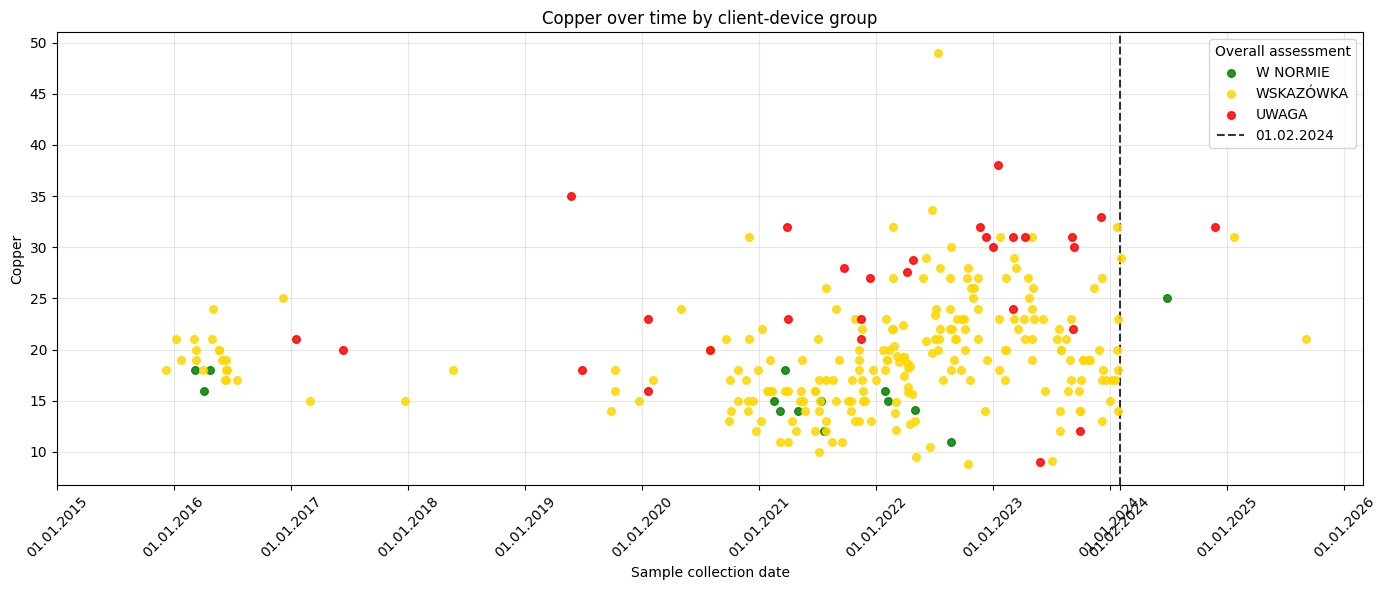

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


df_plot = filtered_df2[
    ["Sample_Collection_Date", "Overall_Assessment", "Copper", "Client_Device", "Client"]
].copy()

df_plot["Sample_Collection_Date"] = pd.to_datetime(
    df_plot["Sample_Collection_Date"],
    errors="coerce"
)

df_plot["Copper"] = pd.to_numeric(
    df_plot["Copper"],
    errors="coerce"
)

df_plot["Overall_Assessment_clean"] = (
    df_plot["Overall_Assessment"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_plot["Client_Device_Group"] = (
    df_plot["Client"].astype(str).str.strip()
    + " / "
    + df_plot["Client_Device"].astype(str).str.strip()
)

df_plot = df_plot.dropna(
    subset=["Sample_Collection_Date", "Copper", "Client", "Client_Device"]
)

df_plot = df_plot.sort_values(
    ["Client_Device_Group", "Sample_Collection_Date"]
)

color_map = {
    "W NORMIE": "green",
    "WSKAZÓWKA": "gold",
    "UWAGA": "red",
}


plt.figure(figsize=(14, 6))

# points keep their own class color
for assessment, color in color_map.items():
    subset = df_plot[df_plot["Overall_Assessment_clean"] == assessment]

    plt.scatter(
        subset["Sample_Collection_Date"],
        subset["Copper"],
        color=color,
        label=assessment,
        alpha=0.85,
        s=30,
        zorder=3,
    )

# vertical reference date
reference_date = pd.Timestamp("2024-02-01")

plt.axvline(
    reference_date,
    color="black",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    label="01.02.2024",
    zorder=2,
)

# force 01.02.2024 to be shown as one of the x-axis ticks
ax = plt.gca()
current_ticks = list(ax.get_xticks())
reference_tick = mdates.date2num(reference_date)

if reference_tick not in current_ticks:
    ax.set_xticks(current_ticks + [reference_tick])

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y"))

plt.xlabel("Sample collection date")
plt.ylabel("Copper")
plt.title("Copper over time by client-device group")
plt.legend(title="Overall assessment")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

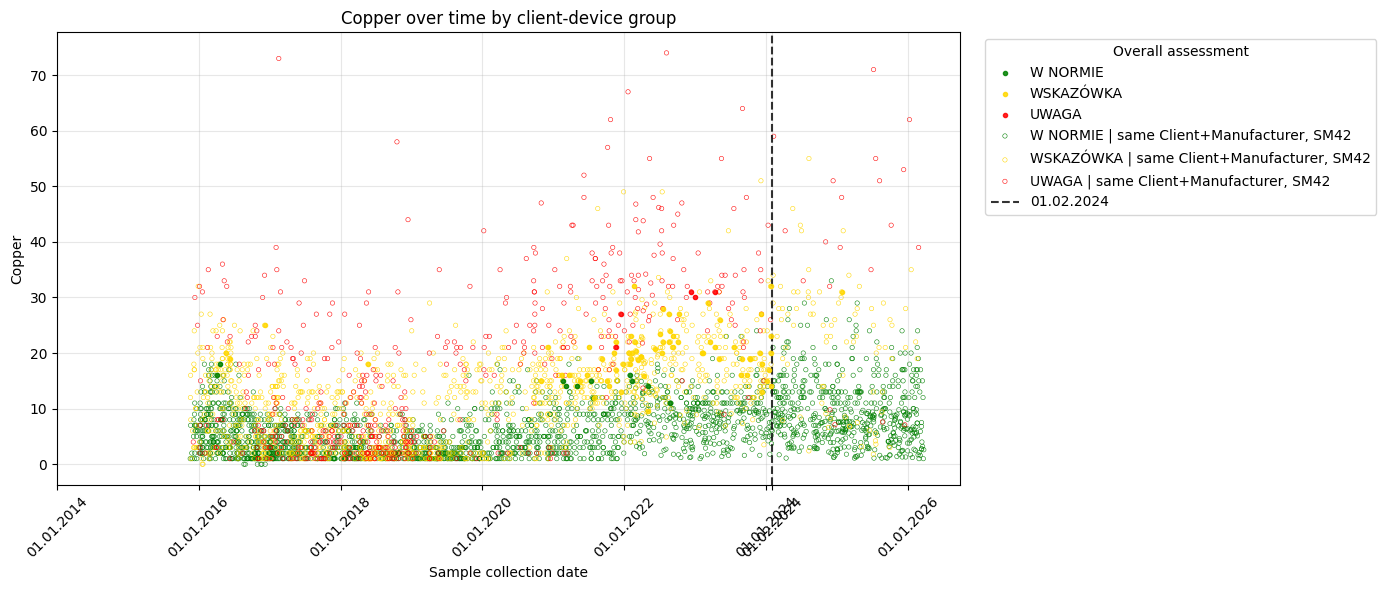

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# Main plot data: only filtered_df2
# ============================================================

df_plot = filtered_df2[
    [
        "Sample_Collection_Date",
        "Overall_Assessment",
        "Copper",
        "Client_Device",
        "Client",
        "Manufacturer",
    ]
].copy()

df_plot["Sample_Collection_Date"] = pd.to_datetime(
    df_plot["Sample_Collection_Date"],
    errors="coerce"
)

df_plot["Copper"] = pd.to_numeric(
    df_plot["Copper"],
    errors="coerce"
)

df_plot["Overall_Assessment_clean"] = (
    df_plot["Overall_Assessment"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_plot["Client_Device_Group"] = (
    df_plot["Client"].astype(str).str.strip()
    + " / "
    + df_plot["Client_Device"].astype(str).str.strip()
)

df_plot = df_plot.dropna(
    subset=["Sample_Collection_Date", "Copper", "Client", "Client_Device"]
)

df_plot = df_plot.sort_values(
    ["Client_Device_Group", "Sample_Collection_Date"]
)


# ============================================================
# Extra outline points: taken from full df, not filtered_df2
# ============================================================

# Client + Manufacturer combinations present in filtered_df2
client_manufacturer_pairs = (
    df_plot[["Client", "Manufacturer"]]
    .drop_duplicates()
)

df_outline = df[
    [
        "Sample_Collection_Date",
        "Overall_Assessment",
        "Copper",
        "Client_Device",
        "Client",
        "Manufacturer",
    ]
].copy()

df_outline["Sample_Collection_Date"] = pd.to_datetime(
    df_outline["Sample_Collection_Date"],
    errors="coerce"
)

df_outline["Copper"] = pd.to_numeric(
    df_outline["Copper"],
    errors="coerce"
)

df_outline["Overall_Assessment_clean"] = (
    df_outline["Overall_Assessment"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_outline = df_outline.dropna(
    subset=["Sample_Collection_Date", "Copper", "Client", "Client_Device", "Manufacturer"]
)

# keep only rows with the same Client + Manufacturer as in filtered_df2
df_outline = df_outline.merge(
    client_manufacturer_pairs,
    on=["Client", "Manufacturer"],
    how="inner"
)

# keep only devices containing SM42
df_outline = df_outline[
    df_outline["Client_Device"]
    .astype(str)
    .str.contains("SM42", case=False, na=False)
]

df_plot = df_plot[df_plot["Copper"] < 75]
df_outline = df_outline[df_outline["Copper"] < 75]


# ============================================================
# Plot
# ============================================================

color_map = {
    "W NORMIE": "green",
    "WSKAZÓWKA": "gold",
    "UWAGA": "red",
}

plt.figure(figsize=(14, 6))

# main filled points from filtered_df2
for assessment, color in color_map.items():
    subset = df_plot[df_plot["Overall_Assessment_clean"] == assessment]

    plt.scatter(
        subset["Sample_Collection_Date"],
        subset["Copper"],
        color=color,
        label=assessment,
        alpha=0.85,
        s=9,
        zorder=3,
    )

# hollow outline points from full df
for assessment, color in color_map.items():
    subset = df_outline[df_outline["Overall_Assessment_clean"] == assessment]

    plt.scatter(
        subset["Sample_Collection_Date"],
        subset["Copper"],
        facecolors="none",
        edgecolors=color,
        linewidths=0.4,
        s=10,
        alpha=0.95,
        label=f"{assessment} | same Client+Manufacturer, SM42",
        zorder=1,
    )

# vertical reference date
reference_date = pd.Timestamp("2024-02-01")

plt.axvline(
    reference_date,
    color="black",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    label="01.02.2024",
    zorder=2,
)

# force reference date as x tick
ax = plt.gca()
current_ticks = list(ax.get_xticks())
reference_tick = mdates.date2num(reference_date)

if reference_tick not in current_ticks:
    ax.set_xticks(current_ticks + [reference_tick])

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y"))

plt.xlabel("Sample collection date")
plt.ylabel("Copper")
plt.title("Copper over time by client-device group")
plt.legend(title="Overall assessment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [52]:
reference_date = pd.Timestamp("2024-02-01")

newer_labnumbers = (
    filtered_df2
    .assign(
        Sample_Collection_Date=pd.to_datetime(
            filtered_df2["Sample_Collection_Date"],
            errors="coerce"
        )
    )
    .loc[
        lambda df: df["Sample_Collection_Date"] > reference_date,
        ["Lab_Number", "Sample_Collection_Date", "Overall_Assessment", "Copper", "Client", "Client_Device", "Manufacturer"]
    ]
    .sort_values("Sample_Collection_Date")
)

newer_labnumbers

,Lab_Number,Sample_Collection_Date,Overall_Assessment,Copper,Client,Client_Device,Manufacturer
245,P2402159,2024-02-06 00:00:00,WSKAZÓWKA,29.0,21802,SM42-1216,CATERPILLAR
253,P2411033,2024-06-27 00:00:00,W NORMIE,25.0,21802,SM42-1259,CATERPILLAR
329,P2420459,2024-11-23 07:20:00,UWAGA,32.0,21802,SM42-1230,CATERPILLAR
330,P2502297,2025-01-24 00:00:00,WSKAZÓWKA,31.0,21802,SM42-1308,CATERPILLAR
235,P2516439,2025-09-05 10:00:00,WSKAZÓWKA,21.0,21802,SM42-1308,CATERPILLAR


In [55]:
df[df["Lab_Number"] == "P2411033"]['Overall_Interpretation'].values[0]

'Oznaczona lepkość w normie dla klasy SAE 40. Temperatura zapłonu w normie. Zawartość miedzi podniesiona, jednak biorąc pod uwagę historię badań jej poziom jest stabilny jak na 1000mth. Poziom pozostałych metalicznych produktów zużycia oznaczony w badaniu pierwiastków w normie.\n\nWnioski i zalecenia:\n\nProszę obserwować zmiany w następnej analizie, zgodnie z harmonogramem diagnostyki.'

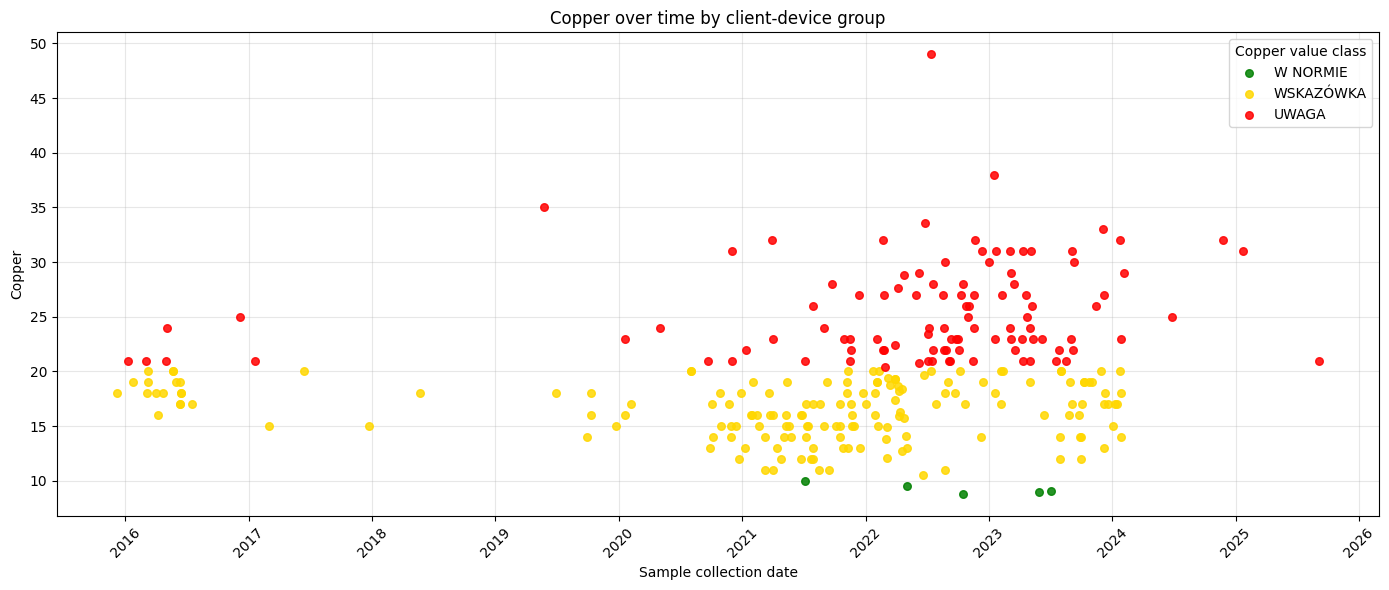

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_plot = filtered_df2[
    ["Sample_Collection_Date", "Copper", "Client_Device", "Client"]
].copy()

df_plot["Sample_Collection_Date"] = pd.to_datetime(
    df_plot["Sample_Collection_Date"],
    errors="coerce"
)

df_plot["Copper"] = pd.to_numeric(
    df_plot["Copper"],
    errors="coerce"
)

df_plot["Client_Device_Group"] = (
    df_plot["Client"].astype(str).str.strip()
    + " / "
    + df_plot["Client_Device"].astype(str).str.strip()
)

df_plot = df_plot.dropna(
    subset=["Sample_Collection_Date", "Copper", "Client", "Client_Device"]
)

df_plot = df_plot.sort_values(
    ["Client_Device_Group", "Sample_Collection_Date"]
)

# classify by Copper value
conditions = [
    df_plot["Copper"].between(0, 10, inclusive="both"),
    df_plot["Copper"].gt(10) & df_plot["Copper"].le(20),
    df_plot["Copper"].gt(20),
]

choices = [
    "W NORMIE",
    "WSKAZÓWKA",
    "UWAGA",
]

df_plot["Copper_Class"] = np.select(
    conditions,
    choices,
    default="UNKNOWN"
)

color_map = {
    "W NORMIE": "green",
    "WSKAZÓWKA": "gold",
    "UWAGA": "red",
    "UNKNOWN": "gray",
}

plt.figure(figsize=(14, 6))

# points colored by Copper value class
for copper_class, color in color_map.items():
    subset = df_plot[df_plot["Copper_Class"] == copper_class]

    if subset.empty:
        continue

    plt.scatter(
        subset["Sample_Collection_Date"],
        subset["Copper"],
        color=color,
        label=copper_class,
        alpha=0.85,
        s=30,
        zorder=3,
    )

plt.xlabel("Sample collection date")
plt.ylabel("Copper")
plt.title("Copper over time by client-device group")
plt.legend(title="Copper value class")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_lower_18 = df_inconsistent[
    pd.to_numeric(df_inconsistent["Copper"], errors="coerce") < 18
].copy()

In [49]:
df_lower_18[['Lab_Number', 'Overall_Interpretation', 'Overall_Assessment']].to_csv("samples_with_copper_below_18.csv", index=False)

In [ ]:
c = df_inconsistent[
    pd.to_numeric(df_inconsistent["Copper"], errors="coerce") < 18
].copy()

In [17]:
inconsistent_groups.to_csv("inconsistent_samples.csv", index=False)

In [14]:
key_name = "miedź"
target_value = "podniesiony"
target_assessment = "W NORMIE"

filtered_df = pd.DataFrame([
    {
        "Lab_Number": lab,
        key_name: parsed.get(key_name),
    }
    for lab, parsed in data.items()
    if parsed.get(key_name) == target_value
])

filtered_df = filtered_df.merge(
    df[["Lab_Number", "Overall_Assessment", "Overall_Interpretation"]],
    on="Lab_Number",
    how="left"
)

filtered_df["Overall_Assessment_norm"] = (
    filtered_df["Overall_Assessment"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.upper()
)

filtered_df = filtered_df.loc[
    filtered_df["Overall_Assessment_norm"] == target_assessment,
    ["Lab_Number", "Overall_Assessment", key_name, "Overall_Interpretation"]
].copy()

print(f"Liczba próbek: {len(filtered_df)}")

filtered_df

Liczba próbek: 39


,Lab_Number,Overall_Assessment,miedź,Overall_Interpretation
21,P1601599,W NORMIE,podniesiony,"Poziom miedzi podniesiony, trend stabilny. Wsz..."
25,P1501659,W NORMIE,podniesiony,PQ indeks informujący o magnetycznych cząstkac...
54,P1503411,W NORMIE,podniesiony,Zawartość wody w normie. Poziom miedzi podnie...
68,P1601171,W NORMIE,podniesiony,Poziom miedzi podniesiony. Wszystkie pozostałe...
70,P1600751,W NORMIE,podniesiony,W efekcie zużycia i/lub korozji poziom miedzi ...
72,P1601476,W NORMIE,podniesiony,"Poziom miedzi podniesiony, trend stabilny. Wsz..."
86,P1602283,W NORMIE,podniesiony,Poziom miedzi podniesiony. Temperatura zapłonu...
164,P1805605,W NORMIE,podniesiony,Oznaczenie klasy czystości oraz poziomu cząste...
408,P2103659,W NORMIE,podniesiony,Oznaczona lepkość w normie. Temperatura zapłon...
411,P2103002,W NORMIE,podniesiony,Oznaczona lepkość oraz temperatura zapłonu w n...


In [15]:
filtered_df.to_csv(f"filtered_{key_name}_{target_value}_{target_value}.csv", index=False)

In [16]:
import pandas as pd
from collections import Counter

trend_key_counts = Counter()

for parsed in data.values():
    for key in parsed.keys():
        if str(key).startswith("trend_"):
            trend_key_counts[key] += 1

trend_keys_df = (
    pd.DataFrame(
        trend_key_counts.items(),
        columns=["trend_key", "count"]
    )
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print(f"Number of unique trend keys: {len(trend_keys_df)}")

trend_keys_df

Number of unique trend keys: 38


,trend_key,count
0,trend_miedź,827
1,trend_metale_zużyciowe,668
2,trend_lepkość,307
3,trend_sód,285
4,trend_ołów,215
5,trend_żelazo,195
6,trend_płyn_chłodniczy,173
7,trend_krzem,173
8,trend_cynk,113
9,trend_ogólny,107


In [17]:
len(data)

24015

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

rows = []

for lab_number, parsed in data.items():
    for key, description in parsed.items():
        rows.append({
            "Lab_Number": lab_number,
            "key": key,
            "description": description,
            "key_description": f"{key}: {description}",
        })

parsed_df = pd.DataFrame(rows)

parsed_df.head()

,Lab_Number,key,description,key_description
0,P1304884,metale_zużyciowe,w_normie,metale_zużyciowe: w_normie
1,P1304884,lepkość,w_normie,lepkość: w_normie
2,P1304884,woda,w_normie,woda: w_normie
3,P1304884,liczba_kwasowa,w_normie,liczba_kwasowa: w_normie
4,P1304884,ph,w_normie,ph: w_normie


In [19]:
# all unique keys
all_keys = sorted(parsed_df["key"].dropna().unique())

# all unique descriptions/statuses
all_descriptions = sorted(parsed_df["description"].dropna().unique())

print("KEYS:")
for k in all_keys:
    print(k)

print("\nDESCRIPTIONS:")
for d in all_descriptions:
    print(d)

KEYS:
azotyny
biokomponenty
bor
chlor
cyna
cynk
dodatki_uszlachetniające
fosfor
glikol
glin
iso_vg
klasa_czystości
krzem
lepkość
liczba_kwasowa
liczba_zasadowa
magnez
metale_zużyciowe
miedź
nitracja
oksydacja
olej_napędowy
oznaczone_parametry
ołów
paliwo
ph
pienienie
potas
pozostałe_parametry
pozostałość_po_spopieleniu
pq_indeks
płyn_chłodniczy
rezerwa_alkaliczna
sadza
stałe_ciała_obce
sulfacja
sód
temperatura_krystalizacji
temperatura_zapłonu
trend_azotyny
trend_biokomponenty
trend_bor
trend_cyna
trend_cynk
trend_dodatki_uszlachetniające
trend_fosfor
trend_glikol
trend_glin
trend_krzem
trend_lepkość
trend_liczba_kwasowa
trend_liczba_zasadowa
trend_magnez
trend_metale_zużyciowe
trend_miedź
trend_nitracja
trend_ogólny
trend_oksydacja
trend_olej_napędowy
trend_ołów
trend_paliwo
trend_ph
trend_potas
trend_pozostałość_po_spopieleniu
trend_pq_indeks
trend_płyn_chłodniczy
trend_rezerwa_alkaliczna
trend_sadza
trend_stałe_ciała_obce
trend_sulfacja
trend_sód
trend_temperatura_krystalizacji
tren

In [20]:
key_name = "metale_zużyciowe"

miedz_descriptions = (
    parsed_df.loc[parsed_df["key"] == key_name, "description"]
    .value_counts()
    .rename_axis("description")
    .reset_index(name="count")
)

miedz_descriptions

,description,count
0,w_normie,8532
1,w_dopuszczalnym_zakresie,1425
2,w_akceptowalnym_zakresie,437
3,podniesiony,191
4,lekko_podniesiony,89
5,znacznie_podniesiony,36
6,krytycznie_podniesiony,18
7,obniżony,14
8,wysoki,12
9,w_zakresie_bezpiecznym,7


In [21]:
key_name = "miedź"

miedz_descriptions = (
    parsed_df.loc[parsed_df["key"] == key_name, "description"]
    .value_counts()
    .rename_axis("description")
    .reset_index(name="count")
)

miedz_descriptions

,description,count
0,podniesiony,1177
1,lekko_podniesiony,580
2,znacznie_podniesiony,299
3,krytycznie_podniesiony,176
4,w_akceptowalnym_zakresie,96
5,w_dopuszczalnym_zakresie,63
6,powyżej_dopuszczalnego_limitu,28
7,nieznacznie_podniesiony,26
8,w_normie,17
9,wysoki,17


In [22]:
MAPPER_3_CLASS = {
    # 0 — w normie / akceptowalne
    "w_normie": 0,
    "w_dopuszczalnym_zakresie": 0,
    "w_akceptowalnym_zakresie": 0,
    "w_zakresie_bezpiecznym": 0,

    # raczej brak danych niż realna klasa
    "nieoznaczono": None,

    # 1 — wskazówka / łagodne odchylenie
    "podniesiony": 1,
    "lekko_podniesiony": 1,
    "nieznacznie_podniesiony": 1,
    "wysoki": 1,
    "obniżony": 1,
    "lekko_obniżony": 1,
    "w_zakresie_granicznym": 1,
    "nietypowy": 1,

    # 2 — uwaga / mocne odchylenie
    "znacznie_podniesiony": 2,
    "krytycznie_podniesiony": 2,
    "znacznie_obniżony": 2,

    # z poprzedniej listy — warto zostawić, jeśli występują gdzie indziej
    "powyżej_dopuszczalnego_limitu": 2,
    "mocno_podwyższony": 2,
    "pogorszony": 1,
}

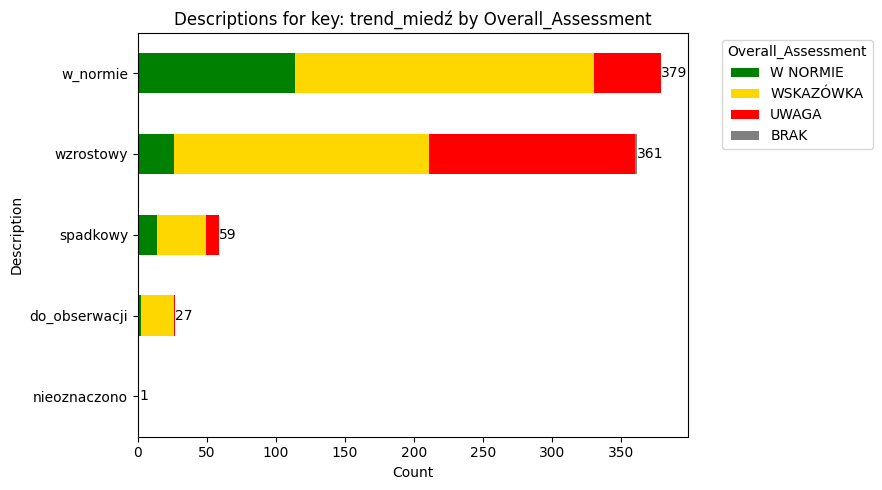

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

key_name = "trend_miedź"
# key_name = "miedź"
# key_name = "metale_zużyciowe"

# 1. Take only rows for miedź
miedz_rows = parsed_df.loc[parsed_df["key"] == key_name].copy()

# 2. Add Overall_Assessment from original df
miedz_rows = miedz_rows.merge(
    df[["Lab_Number", "Overall_Assessment"]],
    on="Lab_Number",
    how="left"
)

# 3. Normalize labels a bit
miedz_rows["Overall_Assessment"] = (
    miedz_rows["Overall_Assessment"]
    .fillna("BRAK")
    .astype(str)
    .str.strip()
    .str.upper()
)

# 4. Count descriptions split by assessment
plot_table = pd.crosstab(
    miedz_rows["description"],
    miedz_rows["Overall_Assessment"]
)

# 5. Keep same order as your previous histogram
description_order = (
    miedz_rows["description"]
    .value_counts()
    .sort_values(ascending=True)
    .index
)

plot_table = plot_table.loc[description_order]

# 6. Make sure columns exist and are in desired order
assessment_order = ["W NORMIE", "WSKAZÓWKA", "UWAGA", "BRAK"]

for col in assessment_order:
    if col not in plot_table.columns:
        plot_table[col] = 0

plot_table = plot_table[assessment_order]

# 7. Colors
colors = {
    "W NORMIE": "green",
    "WSKAZÓWKA": "gold",
    "UWAGA": "red",
    "BRAK": "gray",
}

# 8. Plot stacked horizontal bar chart
ax = plot_table.plot(
    kind="barh",
    stacked=True,
    figsize=(9, 5),
    color=[colors[c] for c in plot_table.columns],
)

plt.xlabel("Count")
plt.ylabel("Description")
plt.title(f"Descriptions for key: {key_name} by Overall_Assessment")
plt.legend(title="Overall_Assessment", bbox_to_anchor=(1.05, 1), loc="upper left")

# 9. Add total count labels at the end of each bar
totals = plot_table.sum(axis=1)

for i, value in enumerate(totals):
    plt.text(value, i, str(value), va="center", ha="left")

plt.tight_layout()
plt.show()

In [24]:
text = "Zawartość miedzi wzrosła od poprzedniego badania, ale mieści się w dopuszczalnym zakresie."

parser.parse_comment(text)

{'miedź': 'w_dopuszczalnym_zakresie', 'trend_miedź': 'wzrostowy'}

In [25]:
def copper_flags(parsed: dict) -> dict:
    """
    Zwraca flagi:
    - miedź_w_normie
    - miedź_wskazówka
    - miedź_podniesiony

    Reguła dodatkowa:
    jeśli metale_zużyciowe == klasa 0, to miedź_w_normie = 1,
    chyba że miedź ma już klasę 1 albo 2.
    """

    out = {
        "miedź_w_normie": 0,
        "miedź_wskazówka": 0,
        "miedź_podniesiony": 0,
    }

    miedz_status = parsed.get("miedź")
    metale_status = parsed.get("metale_zużyciowe")

    miedz_class = MAPPER_3_CLASS.get(miedz_status)
    metale_class = MAPPER_3_CLASS.get(metale_status)

    # Najpierw jawna miedź
    if miedz_class == 0:
        out["miedź_w_normie"] = 1
    elif miedz_class == 1:
        out["miedź_wskazówka"] = 1
    elif miedz_class == 2:
        out["miedź_podniesiony"] = 1

    # Potem fallback z metali zużyciowych:
    # jeśli metale_zużyciowe są w normie, a miedź nie jest wskazówką/podniesiona,
    # to dajemy miedź_w_normie = 1.
    if metale_class == 0:
        if out["miedź_wskazówka"] == 0 and out["miedź_podniesiony"] == 0:
            out["miedź_w_normie"] = 1

    return out

In [26]:
data = parser.df_to_json(df, 0, len(df))

In [27]:
import pandas as pd

rows = []

for lab_number, parsed in data.items():
    row = {"Lab_Number": lab_number}
    row.update(copper_flags(parsed))
    rows.append(row)

miedz_flags_df = pd.DataFrame(rows)

miedz_flags_df.head()

,Lab_Number,miedź_w_normie,miedź_wskazówka,miedź_podniesiony
0,P1304884,1,0,0
1,P1305076,0,0,0
2,P1400113,0,0,0
3,P1400354,0,1,0
4,P1400417,0,0,0


In [28]:
flag_cols = [
    "miedź_w_normie",
    "miedź_wskazówka",
    "miedź_podniesiony",
]

same_zera_mask = miedz_flags_df[flag_cols].sum(axis=1) == 0

n_same_zera = same_zera_mask.sum()
pct_same_zera = 100 * n_same_zera / len(miedz_flags_df)

print(f"Same zera: {n_same_zera} / {len(miedz_flags_df)} ({pct_same_zera:.2f}%)")

Same zera: 12429 / 24015 (51.76%)


In [29]:
missing_lab_numbers = miedz_flags_df.loc[same_zera_mask, "Lab_Number"]

df_missing_original = df[df["Lab_Number"].isin(missing_lab_numbers)].copy()

n_missing_samples = len(df_missing_original)

n_without_copper = df_missing_original["Copper"].isna().sum()
pct_without_copper = 100 * n_without_copper / n_missing_samples

print(
    f'Brakujące próbki bez wartości w kolumnie "Copper": '
    f"{n_without_copper} / {n_missing_samples} ({pct_without_copper:.2f}%)")


Brakujące próbki bez wartości w kolumnie "Copper": 2288 / 12429 (18.41%)


In [30]:
flag_cols = [
    "miedź_w_normie",
    "miedź_wskazówka",
    "miedź_podniesiony",
]

same_zera_mask = miedz_flags_df[flag_cols].sum(axis=1) == 0

miedz_flags_df.loc[same_zera_mask, "miedź_w_normie"] = 1